# Hadamard with spectral leakage **constraint** (not penalty)

Same setup as `hadamard_spectral_proxy.ipynb`, but the spectral leakage is enforced as a hard inequality constraint `|Ω̂(η)|² ≤ ε_max` instead of a soft penalty `R · |Ω̂(η)|²`.

Why: in the penalty form, increasing R pushes |Ω̂(η)|² to its absolute floor at the cost of other goals (notably σ_z robustness). In the constraint form, the optimizer satisfies the leakage bound and then puts all remaining freedom into the objective — which here is just robustness + smoothness. Expected outcome: comparable leakage suppression to the penalty form, *better* robustness.

We optionally keep a small left-over penalty (`R_LEAK_BARRIER`) on top of the constraint for gradient smoothness near the active boundary — the standard interior-point trick.


In [156]:
import Pkg
Pkg.activate(@__DIR__)
piccolo_path       = joinpath(@__DIR__, "..", "..", "..", "Piccolo.jl")
directtrajopt_path = joinpath(@__DIR__, "..", "..", "..", "DirectTrajOpt.jl")
Pkg.develop([
    Pkg.PackageSpec(path = piccolo_path),
    Pkg.PackageSpec(path = directtrajopt_path),
])
Pkg.add(["CairoMakie", "MathTeXEngine", "LaTeXStrings", "JLD2",
         "DataInterpolations", "Ipopt", "QuantumToolbox", "Statistics", "FFTW"])
Pkg.instantiate()

using Piccolo
using LinearAlgebra, Random, Printf, Statistics, JLD2
using CairoMakie, MathTeXEngine, LaTeXStrings
using DataInterpolations: CubicHermiteSpline
using SparseArrays
using FFTW

import DirectTrajOpt.Objectives: AbstractObjective, objective_value, gradient!, hessian_structure, get_full_hessian
import DirectTrajOpt.Constraints: AbstractNonlinearConstraint
import DirectTrajOpt.CommonInterface
# TrajectoryIndexingUtils is bundled via Piccolo; we inline the formula `dim*(k-1) + pos` below.
# get_times, get_timesteps come via `using Piccolo` (which re-exports NamedTrajectories).

set_theme!(Theme(
    fonts = (;
        regular = texfont(:text), bold = texfont(:bold),
        italic = texfont(:italic), bold_italic = texfont(:bolditalic),
        ticks = "TeX Gyre Heros Makie",
    ),
    Axis = (; xgridvisible = false),
))

  Activating project at `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`
   Resolving package versions...
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Project.toml`
  No Changes to `~/Library/Mobile Documents/com~apple~CloudDocs/Documents/GitHub/robust_control_sam/src/hadamard_leakage_tradeoff/Manifest.toml`


## Parameters & operators

In [157]:
# ---- Gate / system parameters (same as hadamard_spectral_proxy.ipynb) ----
const T_NS        = 200.0
const a_bound     = 2π * 0.01            # 10 MHz drive bound
const η_anh       = -2π * 0.170          # -170 MHz anharmonicity (transmon)
const δ_ALC       = η_anh                # |1⟩↔|2⟩ angular frequency
const F_THRESHOLD = 0.9999
const N_KNOTS     = 15
const Δt_GATE     = T_NS / (N_KNOTS - 1)
const Q_R_DEFAULT = 0.0
const Q_R_ROBUST  = 1000.0
const R_DDU       = 10.0
const DDU_BOUND   = 100.0
const ε_MAX       = 0.001                # hard constraint: |Ω̂(η)|² ≤ ε_MAX
const R_LEAK_BARRIER = 0.0               # tiny leftover penalty for gradient smoothness near boundary
const NUM_ITER    = 1000
const SEED        = 42

# 2-level operators
const σx = ComplexF64[0  1; 1  0]
const σy = ComplexF64[0 -im; im 0]
const σz = ComplexF64[1  0; 0 -1]
const I2 = Matrix{ComplexF64}(I, 2, 2)

# 3-level operators (Duffing)
const I3     = Matrix{ComplexF64}(I, 3, 3)
const a3     = ComplexF64[0 1 0; 0 0 sqrt(2); 0 0 0]
const ad3    = adjoint(a3)
const X3     = a3 + ad3
const Y3     = im * (ad3 - a3)
const n3     = ad3 * a3
const H_anh3 = (η_anh / 2) * n3 * (n3 - I3)
const subspace_indices = [1, 2]

const U_target = (1/sqrt(2)) * ComplexF64[1.0  1.0; 1.0 -1.0]
const MHz_per_radperns = 1e3 / (2π)

@printf("T = %.1f ns, η = %.1f MHz, N_knots = %d, ε_max = %.3f, R_barrier = %.0e\n",
    T_NS, η_anh/(2π)*1e3, N_KNOTS, ε_MAX, R_LEAK_BARRIER)


T = 200.0 ns, η = -170.0 MHz, N_knots = 15, ε_max = 0.001, R_barrier = 0e+00


## Custom `SpectralLeakageObjective` (small barrier) and `SpectralLeakageConstraint` (hard bound)

The objective is the same one used in the penalty notebook (kept here at small weight `R_LEAK_BARRIER` to smooth the gradient near the active constraint boundary). The constraint is new: it computes `|Ω̂(η)|² − ε_max` and tells Ipopt it must be ≤ 0.


In [158]:
struct SpectralLeakageObjective <: AbstractObjective
    name::Symbol                    # control variable (expected to be 2 components: u_X, u_Y)
    R::Float64                      # regularization weight
    ω::Float64                      # angular frequency to suppress (rad/ns)
    times::Vector{Float64}          # cached knot times (only valid for fixed Δt)
    Δts::Vector{Float64}            # cached timesteps
    cosωt::Vector{Float64}
    sinωt::Vector{Float64}
end

function SpectralLeakageObjective(name::Symbol, ω::Float64, R::Float64, traj::NamedTrajectory)
    @assert traj.dims[name] == 2 "SpectralLeakageObjective expects 2 components (u_X, u_Y)."
    times = get_times(traj)
    Δts   = get_timesteps(traj)
    return SpectralLeakageObjective(name, R, ω,
        Vector{Float64}(times), Vector{Float64}(Δts),
        cos.(ω .* times), sin.(ω .* times))
end

function objective_value(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    u = traj[obj.name]
    Re_sum = 0.0; Im_sum = 0.0
    @inbounds for k in 1:length(obj.times)
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        Re_sum += Δt * (u[1, k] * c + u[2, k] * s)
        Im_sum += Δt * (u[2, k] * c - u[1, k] * s)
    end
    return obj.R * (Re_sum^2 + Im_sum^2)
end

function gradient!(∇::AbstractVector, obj::SpectralLeakageObjective, traj::NamedTrajectory)
    u = traj[obj.name]
    N = length(obj.times)
    Re_sum = 0.0; Im_sum = 0.0
    @inbounds for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        Re_sum += Δt * (u[1, k] * c + u[2, k] * s)
        Im_sum += Δt * (u[2, k] * c - u[1, k] * s)
    end
    comps = traj.components[obj.name]
    @inbounds for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        # ∂L/∂u_X[k] = 2R·Δt_k·(Re_sum·c - Im_sum·s)
        # ∂L/∂u_Y[k] = 2R·Δt_k·(Re_sum·s + Im_sum·c)
        ∇[idxX] += 2 * obj.R * Δt * (Re_sum * c - Im_sum * s)
        ∇[idxY] += 2 * obj.R * Δt * (Re_sum * s + Im_sum * c)
    end
    return nothing
end

function hessian_structure(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    Z_dim = traj.dim * traj.N + traj.global_dim
    structure = spzeros(Z_dim, Z_dim)
    comps = traj.components[obj.name]
    idxs = Int[]
    for k in 1:traj.N
        push!(idxs, traj.dim * (k - 1) + comps[1])
        push!(idxs, traj.dim * (k - 1) + comps[2])
    end
    for i in idxs, j in idxs
        structure[i, j] = 1.0
    end
    return structure
end

function get_full_hessian(obj::SpectralLeakageObjective, traj::NamedTrajectory)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂²L = spzeros(Z_dim, Z_dim)
    comps = traj.components[obj.name]
    # L = R · (a^T x)² + R · (b^T x)² where x = control vector restricted to (u_X, u_Y) knots.
    # Hessian = 2R · (a aᵀ + b bᵀ).
    N = traj.N
    a = zeros(Z_dim); b = zeros(Z_dim)
    for k in 1:N
        c = obj.cosωt[k]; s = obj.sinωt[k]; Δt = obj.Δts[k]
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        a[idxX] += Δt * c;  a[idxY] += Δt * s
        b[idxX] -= Δt * s;  b[idxY] += Δt * c
    end
    nzs = findall(!iszero, a) ∪ findall(!iszero, b)
    for i in nzs, j in nzs
        v = 2 * obj.R * (a[i]*a[j] + b[i]*b[j])
        if v != 0.0
            ∂²L[i, j] = v
        end
    end
    return ∂²L
end

# ============================================================================
# SpectralLeakageConstraint:  |Ω̂(ω)|² ≤ ε_max  as a hard inequality
# ============================================================================
struct SpectralLeakageConstraint <: AbstractNonlinearConstraint
    name::Symbol
    ω::Float64
    ε_max::Float64
    times_t::Vector{Float64}
    Δts::Vector{Float64}
    cosωt::Vector{Float64}
    sinωt::Vector{Float64}
    dim::Int
    equality::Bool
end

function SpectralLeakageConstraint(name::Symbol, ω::Float64, ε_max::Float64,
                                   traj::NamedTrajectory)
    @assert traj.dims[name] == 2 "SpectralLeakageConstraint expects 2 components (u_X, u_Y)."
    times = get_times(traj)
    Δts   = get_timesteps(traj)
    return SpectralLeakageConstraint(name, ω, ε_max,
        Vector{Float64}(times), Vector{Float64}(Δts),
        cos.(ω .* times), sin.(ω .* times),
        1, false)
end

function _ReIm_sums(c::SpectralLeakageConstraint, u::AbstractMatrix)
    Re_sum = zero(eltype(u))
    Im_sum = zero(eltype(u))
    @inbounds for k in 1:length(c.times_t)
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        Re_sum += Δt_k * (u[1, k] * cos_k + u[2, k] * sin_k)
        Im_sum += Δt_k * (u[2, k] * cos_k - u[1, k] * sin_k)
    end
    return Re_sum, Im_sum
end

function CommonInterface.evaluate!(values::AbstractVector,
                                    c::SpectralLeakageConstraint,
                                    traj::NamedTrajectory)
    u = traj[c.name]
    Re_sum, Im_sum = _ReIm_sums(c, u)
    values[1] = Re_sum^2 + Im_sum^2 - c.ε_max
    return nothing
end

function CommonInterface.eval_jacobian(c::SpectralLeakageConstraint,
                                        traj::NamedTrajectory)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂g = spzeros(c.dim, Z_dim)
    u = traj[c.name]
    Re_sum, Im_sum = _ReIm_sums(c, u)
    comps = traj.components[c.name]
    @inbounds for k in 1:traj.N
        cos_k = c.cosωt[k]; sin_k = c.sinωt[k]; Δt_k = c.Δts[k]
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        # ∂(|Ω̂|²)/∂u_X[k] = 2·Δt_k·(Re_sum·cos - Im_sum·sin)
        # ∂(|Ω̂|²)/∂u_Y[k] = 2·Δt_k·(Re_sum·sin + Im_sum·cos)
        ∂g[1, idxX] = 2 * Δt_k * (Re_sum * cos_k - Im_sum * sin_k)
        ∂g[1, idxY] = 2 * Δt_k * (Re_sum * sin_k + Im_sum * cos_k)
    end
    return ∂g
end

function CommonInterface.eval_hessian_of_lagrangian(c::SpectralLeakageConstraint,
                                                     traj::NamedTrajectory,
                                                     μ::AbstractVector)
    # |Ω̂|² = (aᵀx)² + (bᵀx)²  ⇒  ∇² = 2·(a aᵀ + b bᵀ)
    Z_dim = traj.dim * traj.N + traj.global_dim
    ∂²g = spzeros(Z_dim, Z_dim)
    comps = traj.components[c.name]
    a = zeros(Z_dim); b = zeros(Z_dim)
    @inbounds for k in 1:traj.N
        idxX = traj.dim * (k - 1) + comps[1]
        idxY = traj.dim * (k - 1) + comps[2]
        a[idxX] = c.Δts[k] * c.cosωt[k]
        a[idxY] = c.Δts[k] * c.sinωt[k]
        b[idxX] = -c.Δts[k] * c.sinωt[k]
        b[idxY] =  c.Δts[k] * c.cosωt[k]
    end
    nzs = findall(!iszero, a) ∪ findall(!iszero, b)
    for i in nzs, j in nzs
        v = 2 * μ[1] * (a[i]*a[j] + b[i]*b[j])
        if v != 0.0
            ∂²g[i, j] = v
        end
    end
    return ∂²g
end

println("SpectralLeakageObjective + SpectralLeakageConstraint defined.")


SpectralLeakageObjective + SpectralLeakageConstraint defined.


## 2 variants (with the spectral constraint, no proxy baselines this time)

Default = Q_r = 0 + spectral constraint at ε_max.
Robust  = Q_r = 100 + spectral constraint at ε_max.

Compare these to the penalty-form results in `hadamard_spectral_proxy.ipynb`. Same gate, same fidelity floor, same ddu bounds — only the spectral term changed.


In [159]:
function optimize_2lvl(; robust::Bool, with_proxy::Bool, seed::Int = SEED)
    Random.seed!(seed)
    drive_bounds = fill(a_bound, 2)
    H_fn      = (u, t) -> u[1] * σx + u[2] * σy
    H_vars_fn = Function[(u, t) -> σz]
    varsys = VariationalQuantumSystem(
        H_fn, H_vars_fn, 2, drive_bounds; time_dependent = true)

    times_knots   = collect(range(0.0, T_NS, length = N_KNOTS))
    controls_init = 0.1 .* a_bound .* randn(2, N_KNOTS)
    pulse         = CubicSplinePulse(controls_init, times_knots)

    Q_r = robust ? Q_R_ROBUST : Q_R_DEFAULT

    qcp = VariationalSplinePulseProblem(
        varsys, pulse, U_target;
        Q              = 0.0,
        Q_r            = Q_r,
        R              = 1e-3,
        R_ddu          = R_DDU,
        du_bound       = Inf,
        ddu_bound      = DDU_BOUND,
        Δt_bounds      = (Δt_GATE, Δt_GATE),
        n_path_samples = 3,
    )
    push!(qcp.prob.constraints,
        FinalUnitaryFidelityConstraint(U_target, :Ũ⃗, F_THRESHOLD, get_trajectory(qcp)))

    # Spectral leakage handling — constraint form, plus small leftover penalty
    # for gradient smoothness near the active boundary (interior-point trick).
    if with_proxy
        traj = get_trajectory(qcp)
        spec_constr = SpectralLeakageConstraint(:u, abs(η_anh), ε_MAX, traj)
        push!(qcp.prob.constraints, spec_constr)
        spec_obj = SpectralLeakageObjective(:u, abs(η_anh), R_LEAK_BARRIER, traj)
        qcp.prob.objective = qcp.prob.objective + spec_obj
    end

    label = (robust ? "ROBUST" : "DEFAULT") * (with_proxy ? " + SPECTRAL CONSTRAINT" : "")
    println("\n--- $label optimization ---")
    t0 = time()
    solve!(qcp; max_iter = NUM_ITER, print_level = 0,
        options = IpoptOptions(
            eval_hessian = false, constr_viol_tol = 1e-8,
            tol = 1e-8, acceptable_tol = 1e-8,
        ))
    @printf("solve wall: %.1f s\n", time() - t0)

    return get_trajectory(qcp)
end

traj_d_prox = optimize_2lvl(; robust = false, with_proxy = true)
traj_r_prox = optimize_2lvl(; robust = true,  with_proxy = true)
println("\nBoth constraint-form pulses ready.")


    constructing VariationalSplinePulseProblem...
      pulse type: CubicSplinePulse{CubicHermiteSpline{Matrix{Float64}, Vector{Float64}, Vector{Union{}}, Matrix{Float64}, Vector{Vector{Float64}}, Float64}}
      time_dependent: true
      variational directions: 1
      added augmented state :var_Ũ⃗  dim=16  (1 error channels)
      dynamics spline order: 3
      added DerivativeIntegrator (:du → :ddu) for acceleration bound
      applying TimeStepsAllEqualConstraint
      added CubicHermitePathConstraint: 3 samples/interval, bound=±0.06283

--- DEFAULT + SPECTRAL CONSTRAINT optimization ---
    initializing optimizer...
      building evaluator: 3 integrators, 3 nonlinear constraints
      dynamics constraints: 364, nonlinear constraints: 170
        integrator 1 jacobian structure: 0.01s
        integrator 2 jacobian structure: 0.009s
        integrator 3 jacobian structure: 0.0s
        constraint 1 (CubicHermitePathConstraint) jacobian structure: 0.0s
        constraint 2 (Nonline

## Time-domain controls

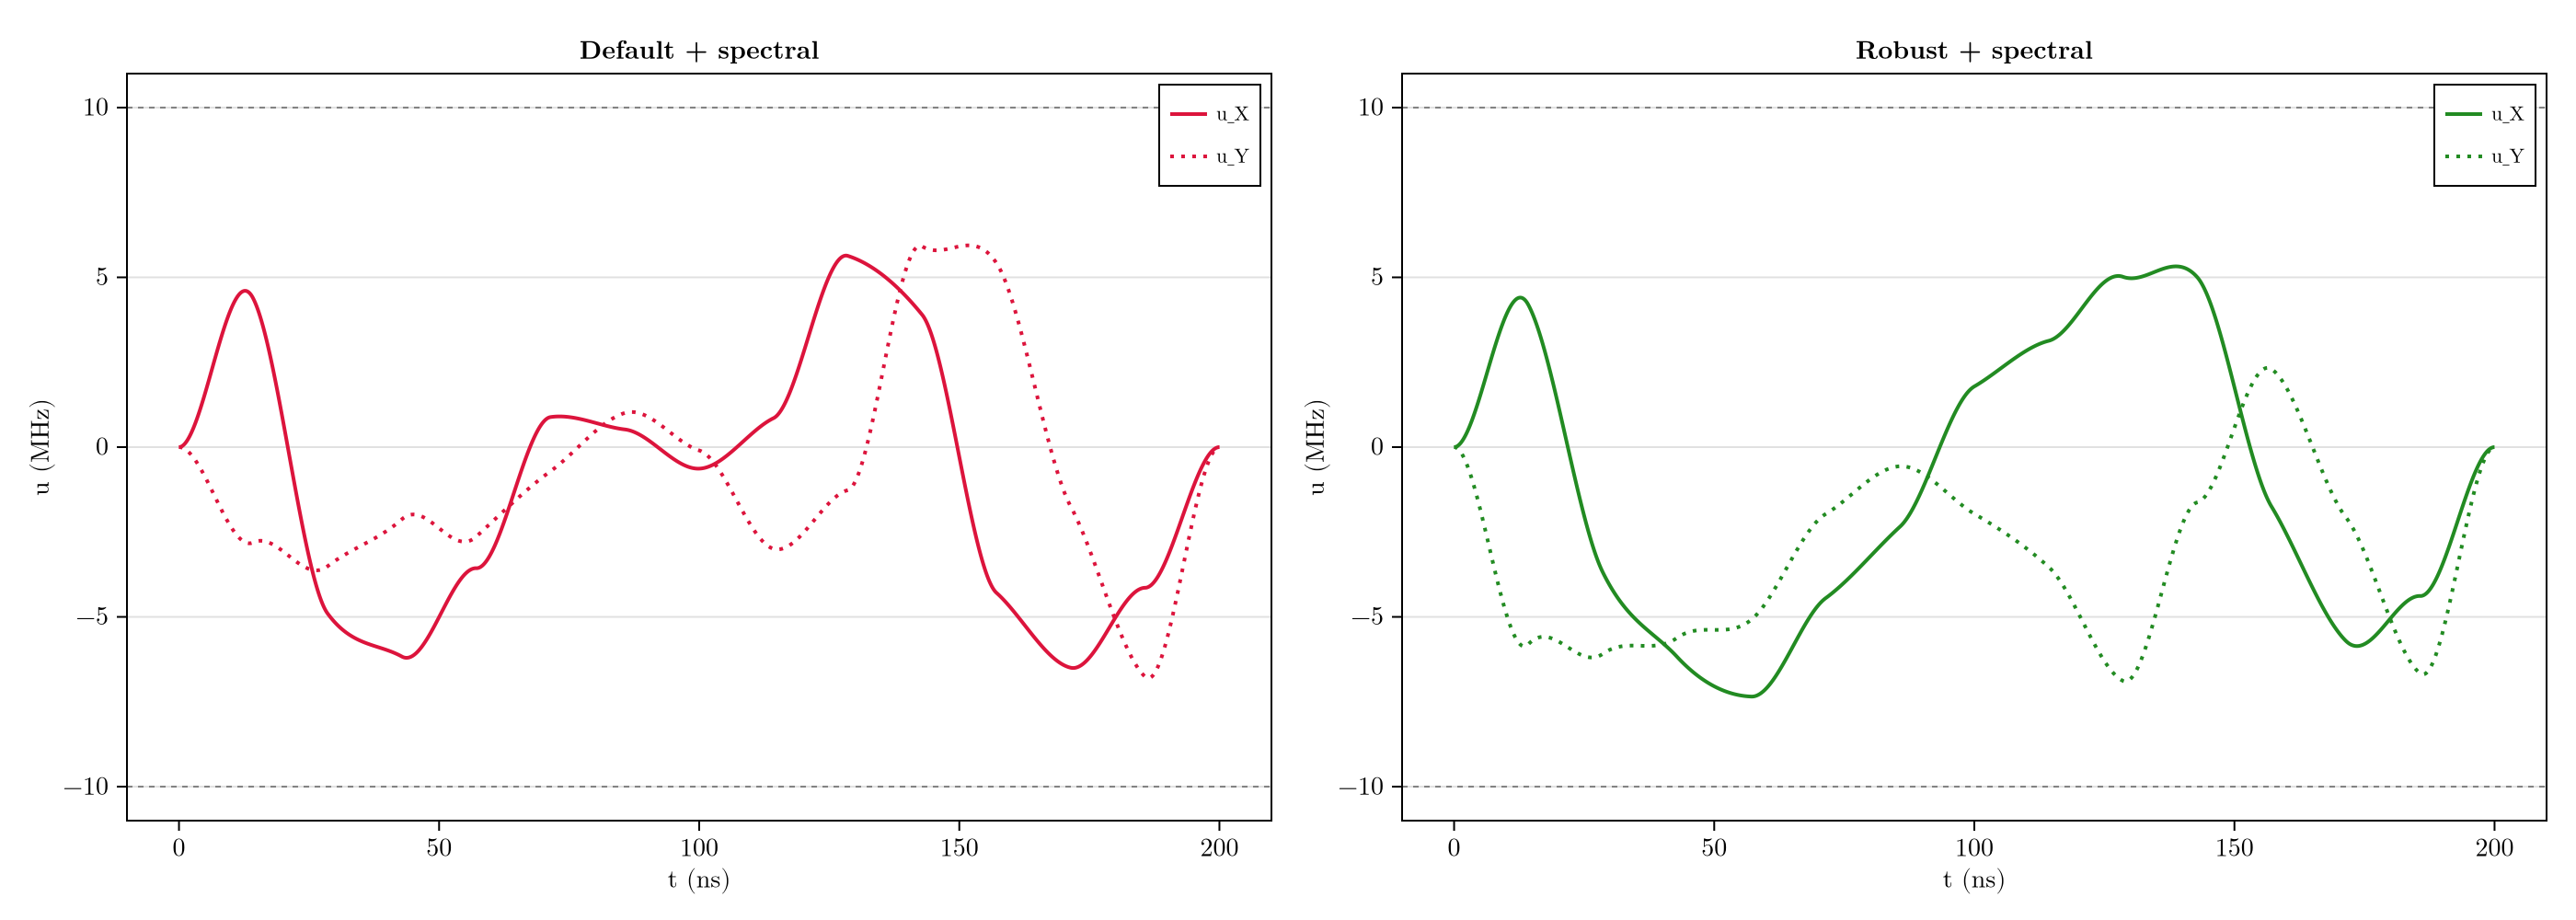

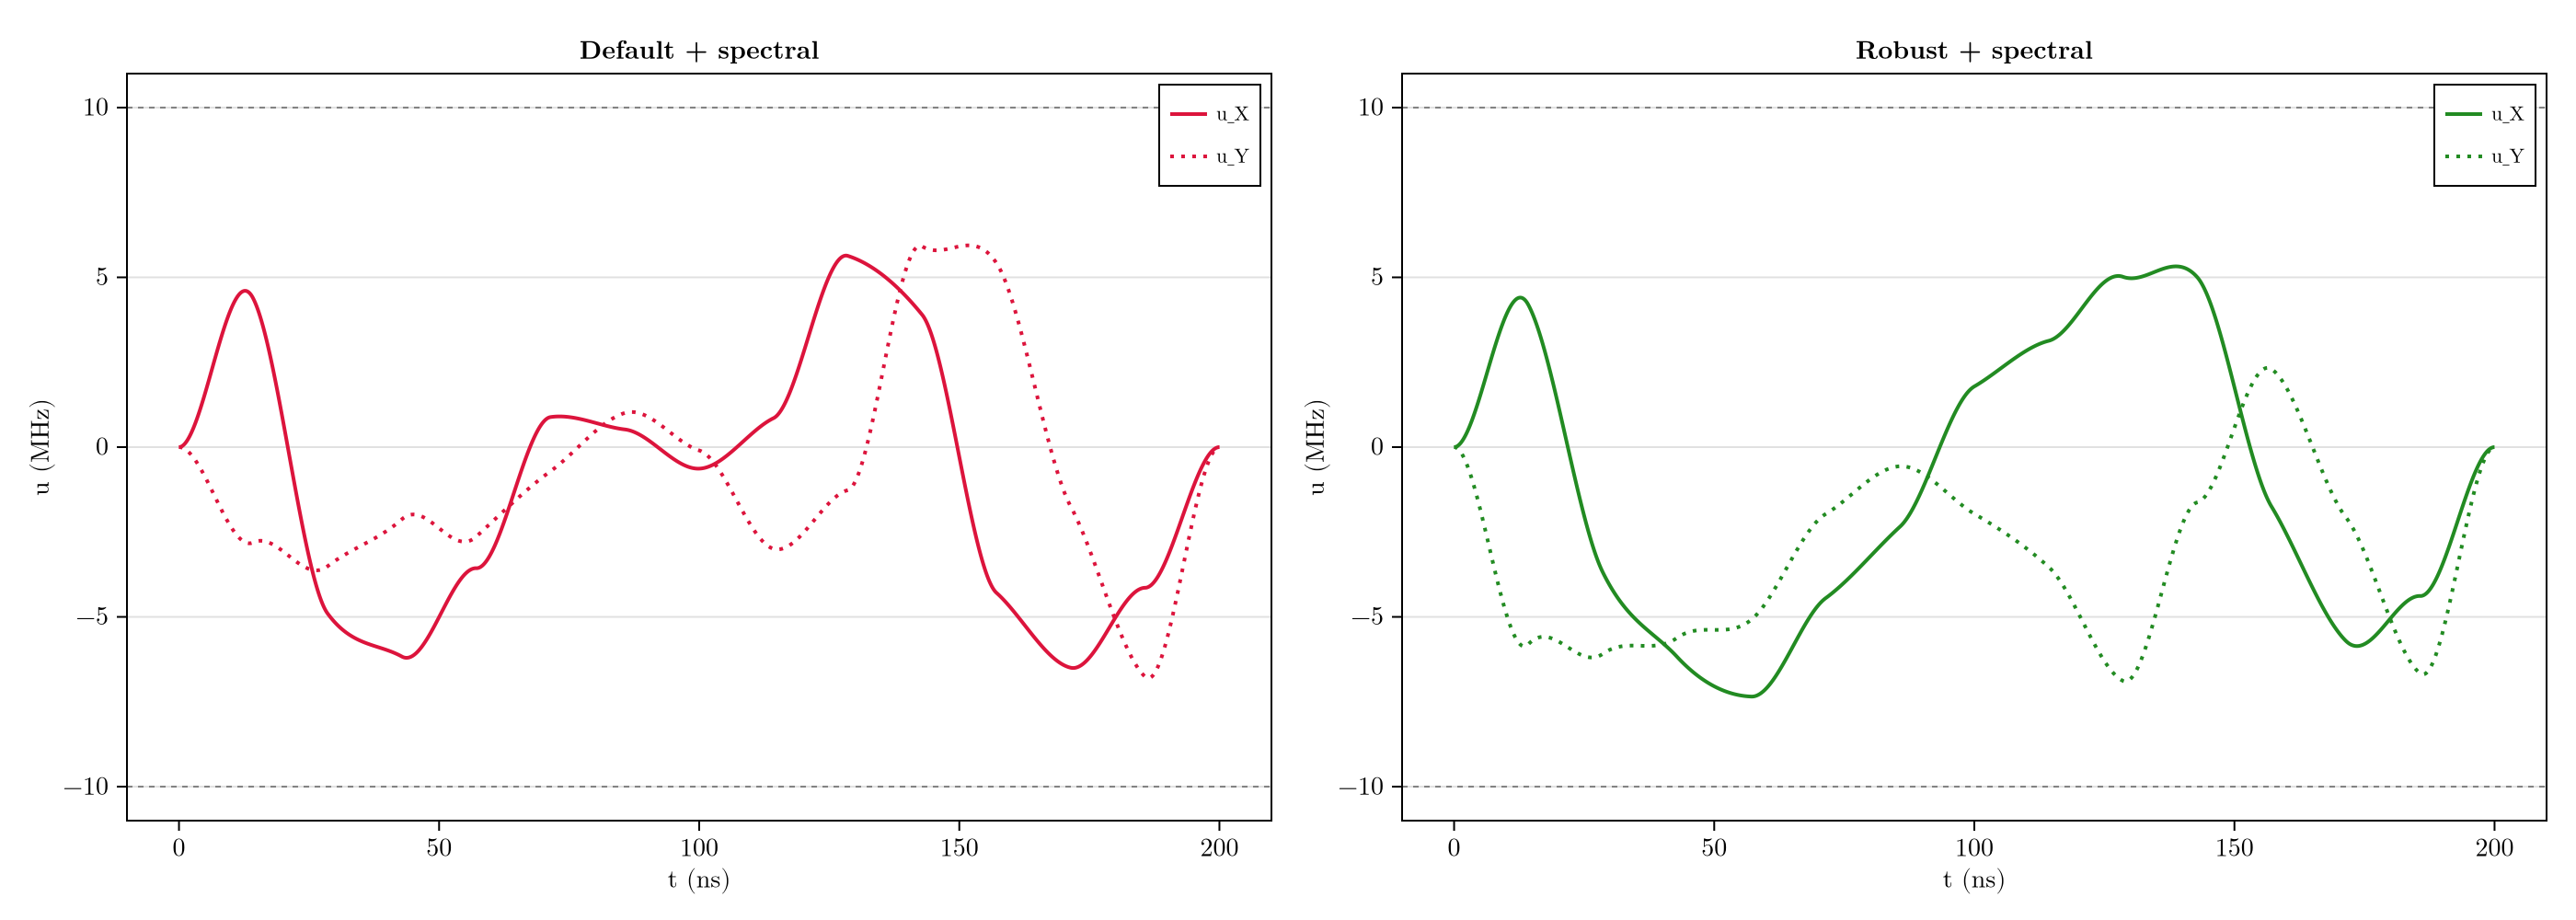

In [160]:
function spline_uXuY(traj)
    us  = traj[:u]; dus = traj[:du]
    ts  = collect(range(0.0, T_NS, length = size(us, 2)))
    return CubicHermiteSpline(dus[1, :], us[1, :], ts),
           CubicHermiteSpline(dus[2, :], us[2, :], ts)
end

ts_fine = collect(range(0.0, T_NS, length = 2000))

function sample_pulse(traj)
    sp_X, sp_Y = spline_uXuY(traj)
    return ([sp_X(t) for t in ts_fine] .* MHz_per_radperns,
            [sp_Y(t) for t in ts_fine] .* MHz_per_radperns)
end

panels = [
    ("Default + spectral", traj_d_prox, :crimson),
    ("Robust + spectral",  traj_r_prox, :forestgreen),
]

fig = Figure(size = (1400, 500), fontsize = 14)
for (i, (lbl, traj, c)) in enumerate(panels)
    ax = Axis(fig[1, i]; xlabel = "t (ns)", ylabel = "u (MHz)", title = lbl)
    uX, uY = sample_pulse(traj)
    lines!(ax, ts_fine, uX; color = c, linewidth = 2.0, label = "u_X")
    lines!(ax, ts_fine, uY; color = c, linewidth = 2.0, linestyle = :dot, label = "u_Y")
    hlines!(ax, [a_bound, -a_bound] .* MHz_per_radperns;
        color = :gray, linestyle = :dash, linewidth = 1)
    axislegend(ax; position = :rt, labelsize = 11)
end
display(fig)
save(joinpath(@__DIR__, "spectral_time_domain.png"), fig; px_per_unit = 4)
fig


## Frequency-domain: |Ω̂(f)|

Dashed vertical line is the leakage transition frequency f₂₁ − f₁₀ = η/(2π). The spectral proxy should push the |Ω̂| value at that frequency much lower.

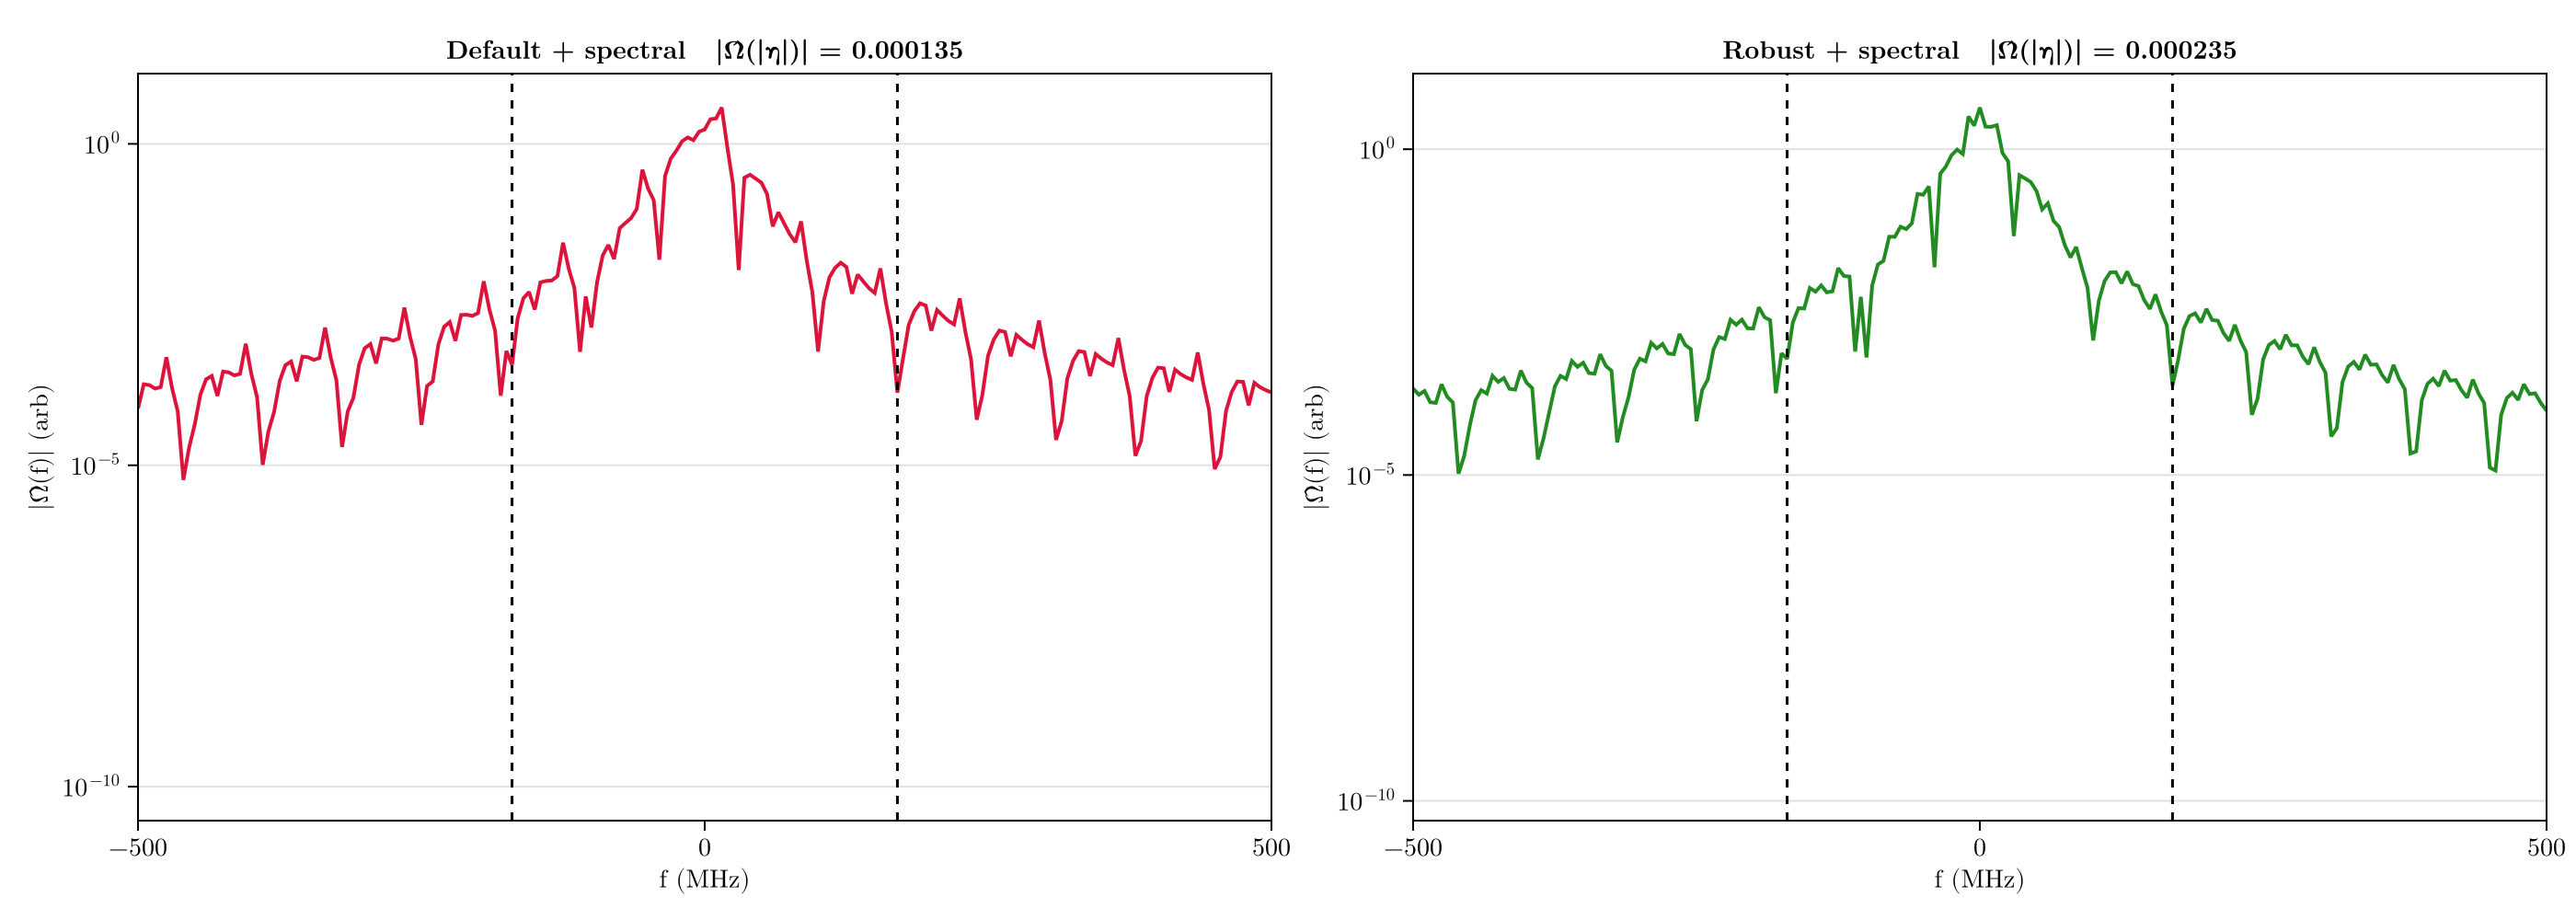

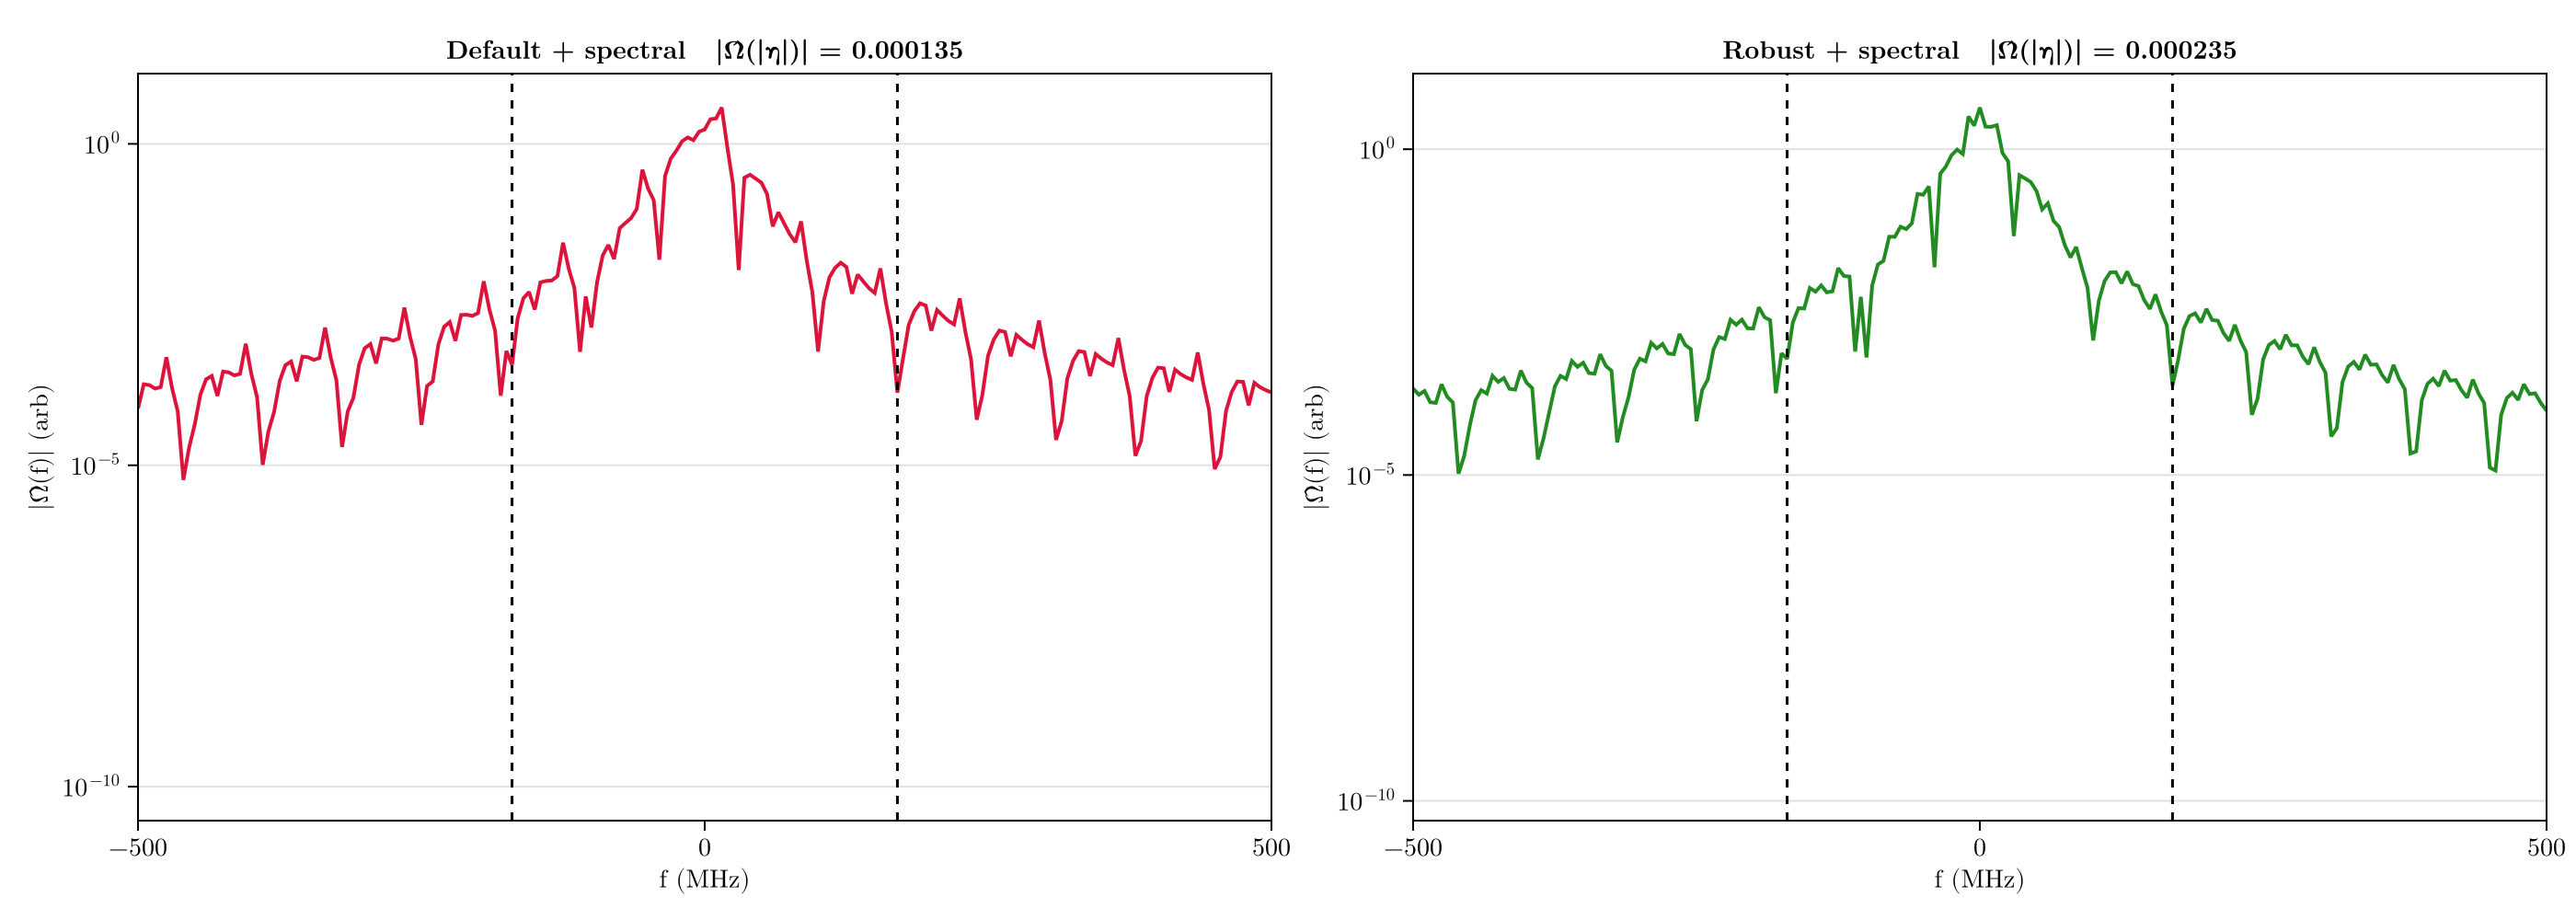

In [161]:
function envelope_spectrum(traj; N_dense = 8192)
    sp_X, sp_Y = spline_uXuY(traj)
    ts_d = collect(range(0.0, T_NS, length = N_dense))
    dt_d = ts_d[2] - ts_d[1]
    Ω = [sp_X(t) + im * sp_Y(t) for t in ts_d]
    Ω̂ = fftshift(fft(Ω)) * dt_d
    fs = fftshift(fftfreq(N_dense, 1/dt_d))    # GHz (since t in ns → 1/ns)
    return fs .* 1e3, abs.(Ω̂)                  # MHz, |Ω̂|
end

η_MHz = η_anh / (2π) * 1e3

fig = Figure(size = (1400, 500), fontsize = 14)
for (i, (lbl, traj, c)) in enumerate(panels)
    fs_MHz, mag = envelope_spectrum(traj)
    Ω_at_η = mag[argmin(abs.(fs_MHz .- abs(η_MHz)))]
    ax = Axis(fig[1, i];
        xlabel = "f (MHz)", ylabel = "|Ω̂(f)| (arb)",
        yscale = log10,
        title = "$(lbl)   |Ω̂(|η|)| = $(round(Ω_at_η, sigdigits=3))")
    lines!(ax, fs_MHz, max.(mag, 1e-10); color = c, linewidth = 2.0)
    vlines!(ax, [η_MHz, -η_MHz]; color = :black, linestyle = :dash, linewidth = 1.5)
    xlims!(ax, -500, 500)
end
display(fig)
save(joinpath(@__DIR__, "spectral_freq_domain.png"), fig; px_per_unit = 4)
fig


## 2-lvl honest verification (`unitary_rollout`, cubic-Hermite spline)

In [162]:
const sys_2lvl = QuantumSystem(zeros(ComplexF64, 2, 2), [σx, σy], fill(a_bound, 2))

function honest_F_2lvl(traj)
    Ũ⃗ = unitary_rollout(traj, sys_2lvl;
        interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
    U_T = iso_vec_to_operator(Ũ⃗[:, end])
    return abs2(tr(U_target' * U_T)) / 4
end

for (lbl, traj, _) in panels
    @printf("%-24s  F_2lvl = %.6f\n", lbl, honest_F_2lvl(traj))
end

Default + spectral        F_2lvl = 0.999998
Robust + spectral         F_2lvl = 0.999998


## 2-lvl QuantumToolbox cross-check (independent ODE solver)

In [163]:
using QuantumToolbox
import QuantumToolbox: Qobj, QobjEvo, sesolve, basis

const σx_qt = Qobj(σx)
const σy_qt = Qobj(σy)
const σz_qt = Qobj(σz)

function F_QT_2lvl(traj; ε = 0.0)
    sp_X, sp_Y = spline_uXuY(traj)
    coef_x = (p, t) -> sp_X(t)
    coef_y = (p, t) -> sp_Y(t)
    H = QobjEvo((ε * σz_qt, (σx_qt, coef_x), (σy_qt, coef_y)))
    U_T = Matrix{ComplexF64}(I, 2, 2)
    for ψ0_idx in 0:1
        ψ0 = basis(2, ψ0_idx)
        sol = sesolve(H, ψ0, [0.0, T_NS]; progress_bar = Val(false),
                      abstol = 1e-12, reltol = 1e-12)
        U_T[:, ψ0_idx + 1] = sol.states[end].data
    end
    return abs2(tr(U_target' * U_T)) / 4
end

for (lbl, traj, _) in panels
    F_pr = honest_F_2lvl(traj)
    F_qt = F_QT_2lvl(traj)
    @printf("%-24s  F_rollout = %.6f   F_QT = %.6f   |Δ| = %.2e\n",
        lbl, F_pr, F_qt, abs(F_pr - F_qt))
end

Default + spectral        F_rollout = 0.999998   F_QT = 0.999998   |Δ| = 3.06e-14
Robust + spectral         F_rollout = 0.999998   F_QT = 0.999998   |Δ| = 2.48e-13


## 3-lvl simulation at ε = 0 (honest leakage check)

In [164]:
function propagate_3lvl_raw(traj, ε; N_fine = 1000)
    sp_X, sp_Y = spline_uXuY(traj)
    ts_f = collect(range(0.0, T_NS, length = N_fine))
    dt_sub = ts_f[2] - ts_f[1]
    U = Matrix{ComplexF64}(I, 3, 3)
    for k in 1:N_fine - 1
        t_mid = 0.5 * (ts_f[k] + ts_f[k+1])
        H = H_anh3 + sp_X(t_mid) * X3 + sp_Y(t_mid) * Y3 + ε * n3
        U = exp(-im * dt_sub * H) * U
    end
    return U
end

function F_L_3lvl(traj; ε = 0.0)
    U_T  = propagate_3lvl_raw(traj, ε)
    Usub = U_T[subspace_indices, subspace_indices]
    F = abs2(tr(U_target' * Usub)) / 4
    L = 1 - real(tr(Usub' * Usub)) / 2
    return F, L
end

for (lbl, traj, _) in panels
    F3, L3 = F_L_3lvl(traj)
    @printf("%-24s  F_3lvl = %.6f   L_3lvl = %.3e\n", lbl, F3, L3)
end

Default + spectral        F_3lvl = 0.988585   L_3lvl = 8.520e-06
Robust + spectral         F_3lvl = 0.995866   L_3lvl = 3.284e-06


## ε-sweep — robustness curves (2-lvl & 3-lvl)

In [165]:
εs = collect(range(-2π*0.01, 2π*0.01, length = 51))   # ±10 MHz in rad/ns
εs_MHz = εs .* MHz_per_radperns

function sweep_2lvl(traj)
    Fs = Float64[]
    for ε in εs
        sys_pert = QuantumSystem(ε * σz, [σx, σy], fill(a_bound, 2))
        Ũ⃗ = unitary_rollout(traj, sys_pert;
            interpolation = :cubic_hermite, abstol = 1e-12, reltol = 1e-12)
        U_T = iso_vec_to_operator(Ũ⃗[:, end])
        push!(Fs, abs2(tr(U_target' * U_T)) / 4)
    end
    return Fs
end

function sweep_3lvl(traj)
    Fs = Float64[]; Ls = Float64[]
    for ε in εs
        F, L = F_L_3lvl(traj; ε = ε)
        push!(Fs, F); push!(Ls, L)
    end
    return Fs, Ls
end

println("Running 2-lvl ε-sweeps...")
@time F2_dp = sweep_2lvl(traj_d_prox);
@time F2_rp = sweep_2lvl(traj_r_prox);

println("Running 3-lvl ε-sweeps...")
@time F3_dp, L3_dp = sweep_3lvl(traj_d_prox);
@time F3_rp, L3_rp = sweep_3lvl(traj_r_prox);

println("Done.")


Running 2-lvl ε-sweeps...
  4.360311 seconds (227.01 M allocations: 11.924 GiB, 18.87% gc time, 0.24% compilation time)
  4.072501 seconds (216.01 M allocations: 11.346 GiB, 17.85% gc time)
Running 3-lvl ε-sweeps...
  0.071581 seconds (1.83 M allocations: 153.478 MiB, 26.18% gc time, 12.89% compilation time)
  0.054357 seconds (1.79 M allocations: 151.721 MiB, 18.81% gc time)
Done.


## F vs ε (2-lvl rollout, σ_z perturbation — robustness curves)

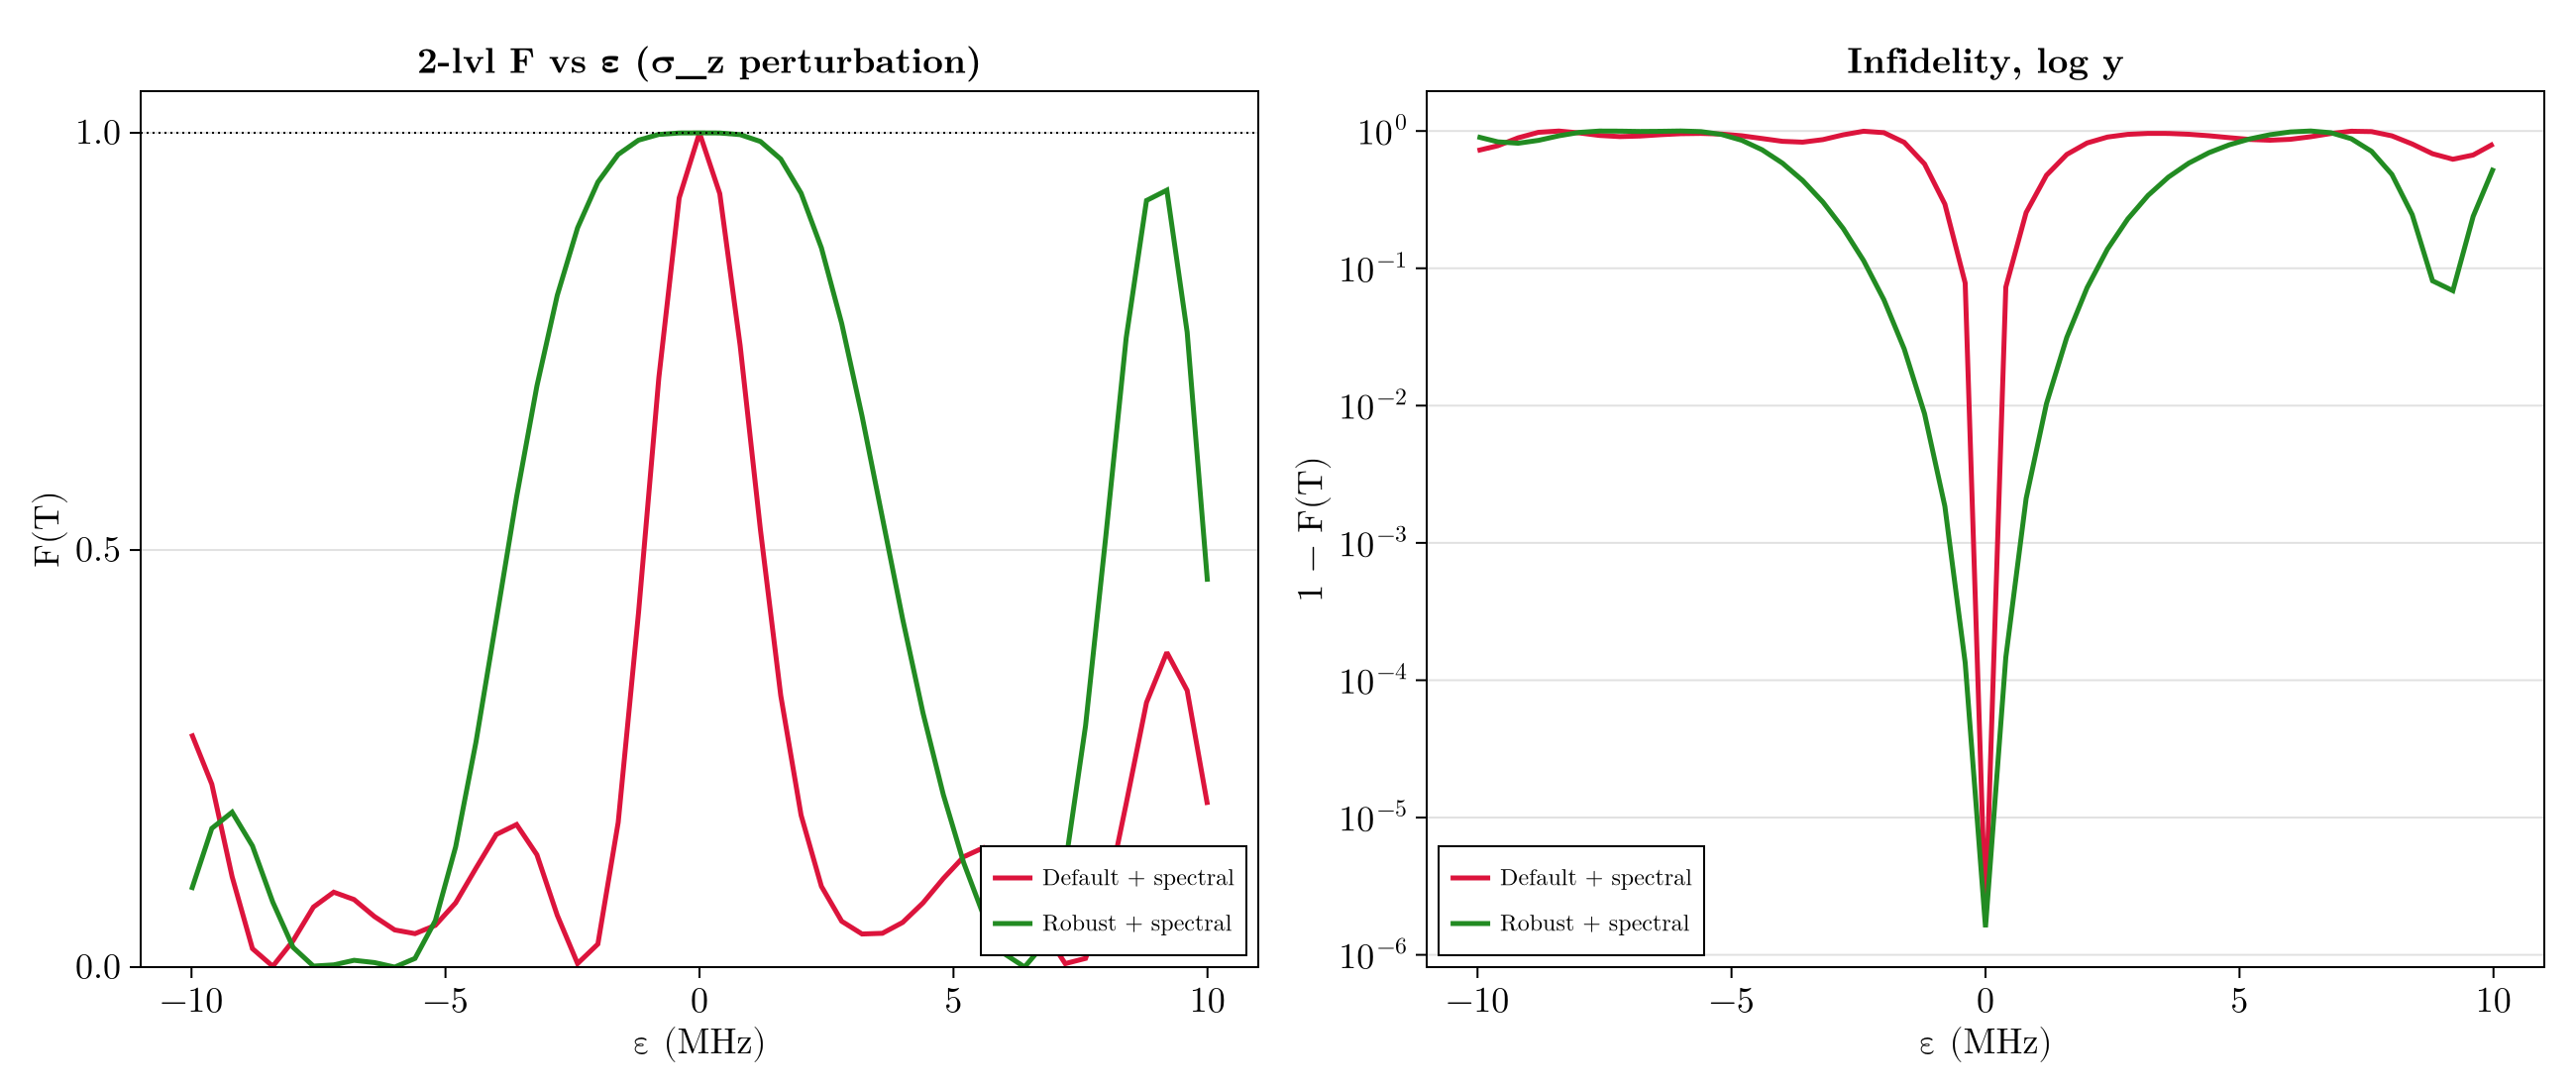

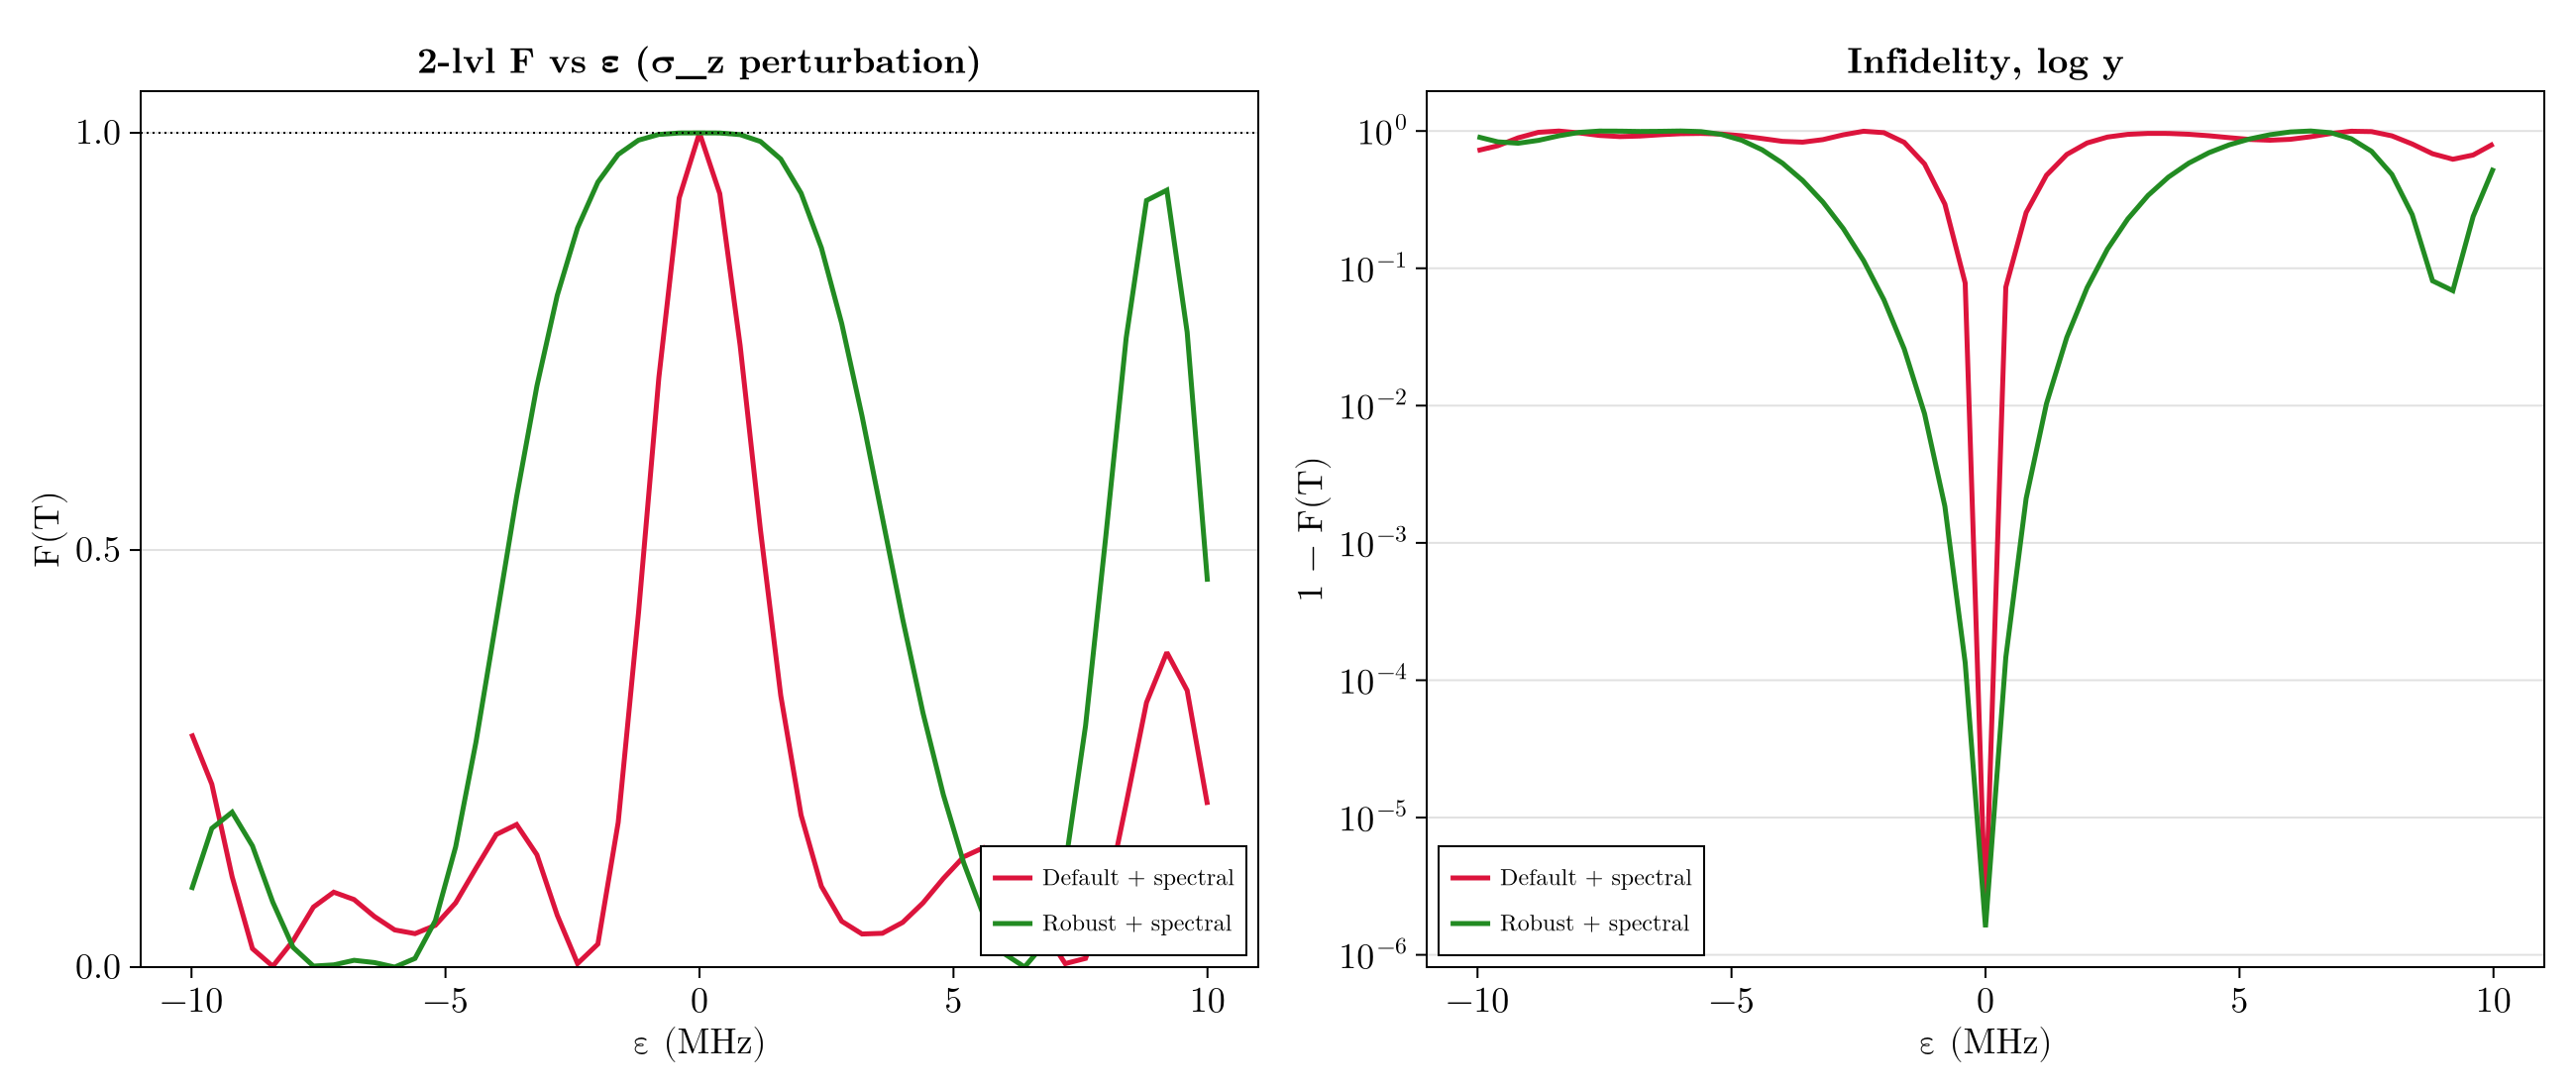

In [166]:
fig = Figure(size = (1300, 550), fontsize = 18)
ax_F  = Axis(fig[1, 1]; xlabel = "ε (MHz)", ylabel = "F(T)",
    title = "2-lvl F vs ε (σ_z perturbation)")
ax_inf = Axis(fig[1, 2]; xlabel = "ε (MHz)", ylabel = "1 − F(T)",
    yscale = log10, title = "Infidelity, log y")

for (lbl, F, c) in [
        ("Default + spectral", F2_dp, :crimson),
        ("Robust + spectral",  F2_rp, :forestgreen),
    ]
    lines!(ax_F,   εs_MHz, F; color = c, linewidth = 2.5, label = lbl)
    lines!(ax_inf, εs_MHz, max.(1 .- F, 1e-12); color = c, linewidth = 2.5, label = lbl)
end
hlines!(ax_F, [1.0]; color = :black, linestyle = :dot, linewidth = 1)
ylims!(ax_F, 0, 1.05)
axislegend(ax_F;   position = :rb, labelsize = 12)
axislegend(ax_inf; position = :lb, labelsize = 12)
display(fig)
save(joinpath(@__DIR__, "spectral_F_vs_eps_2lvl.png"), fig; px_per_unit = 4)
fig


## F and leakage vs ε (3-lvl Duffing, V = n̂)

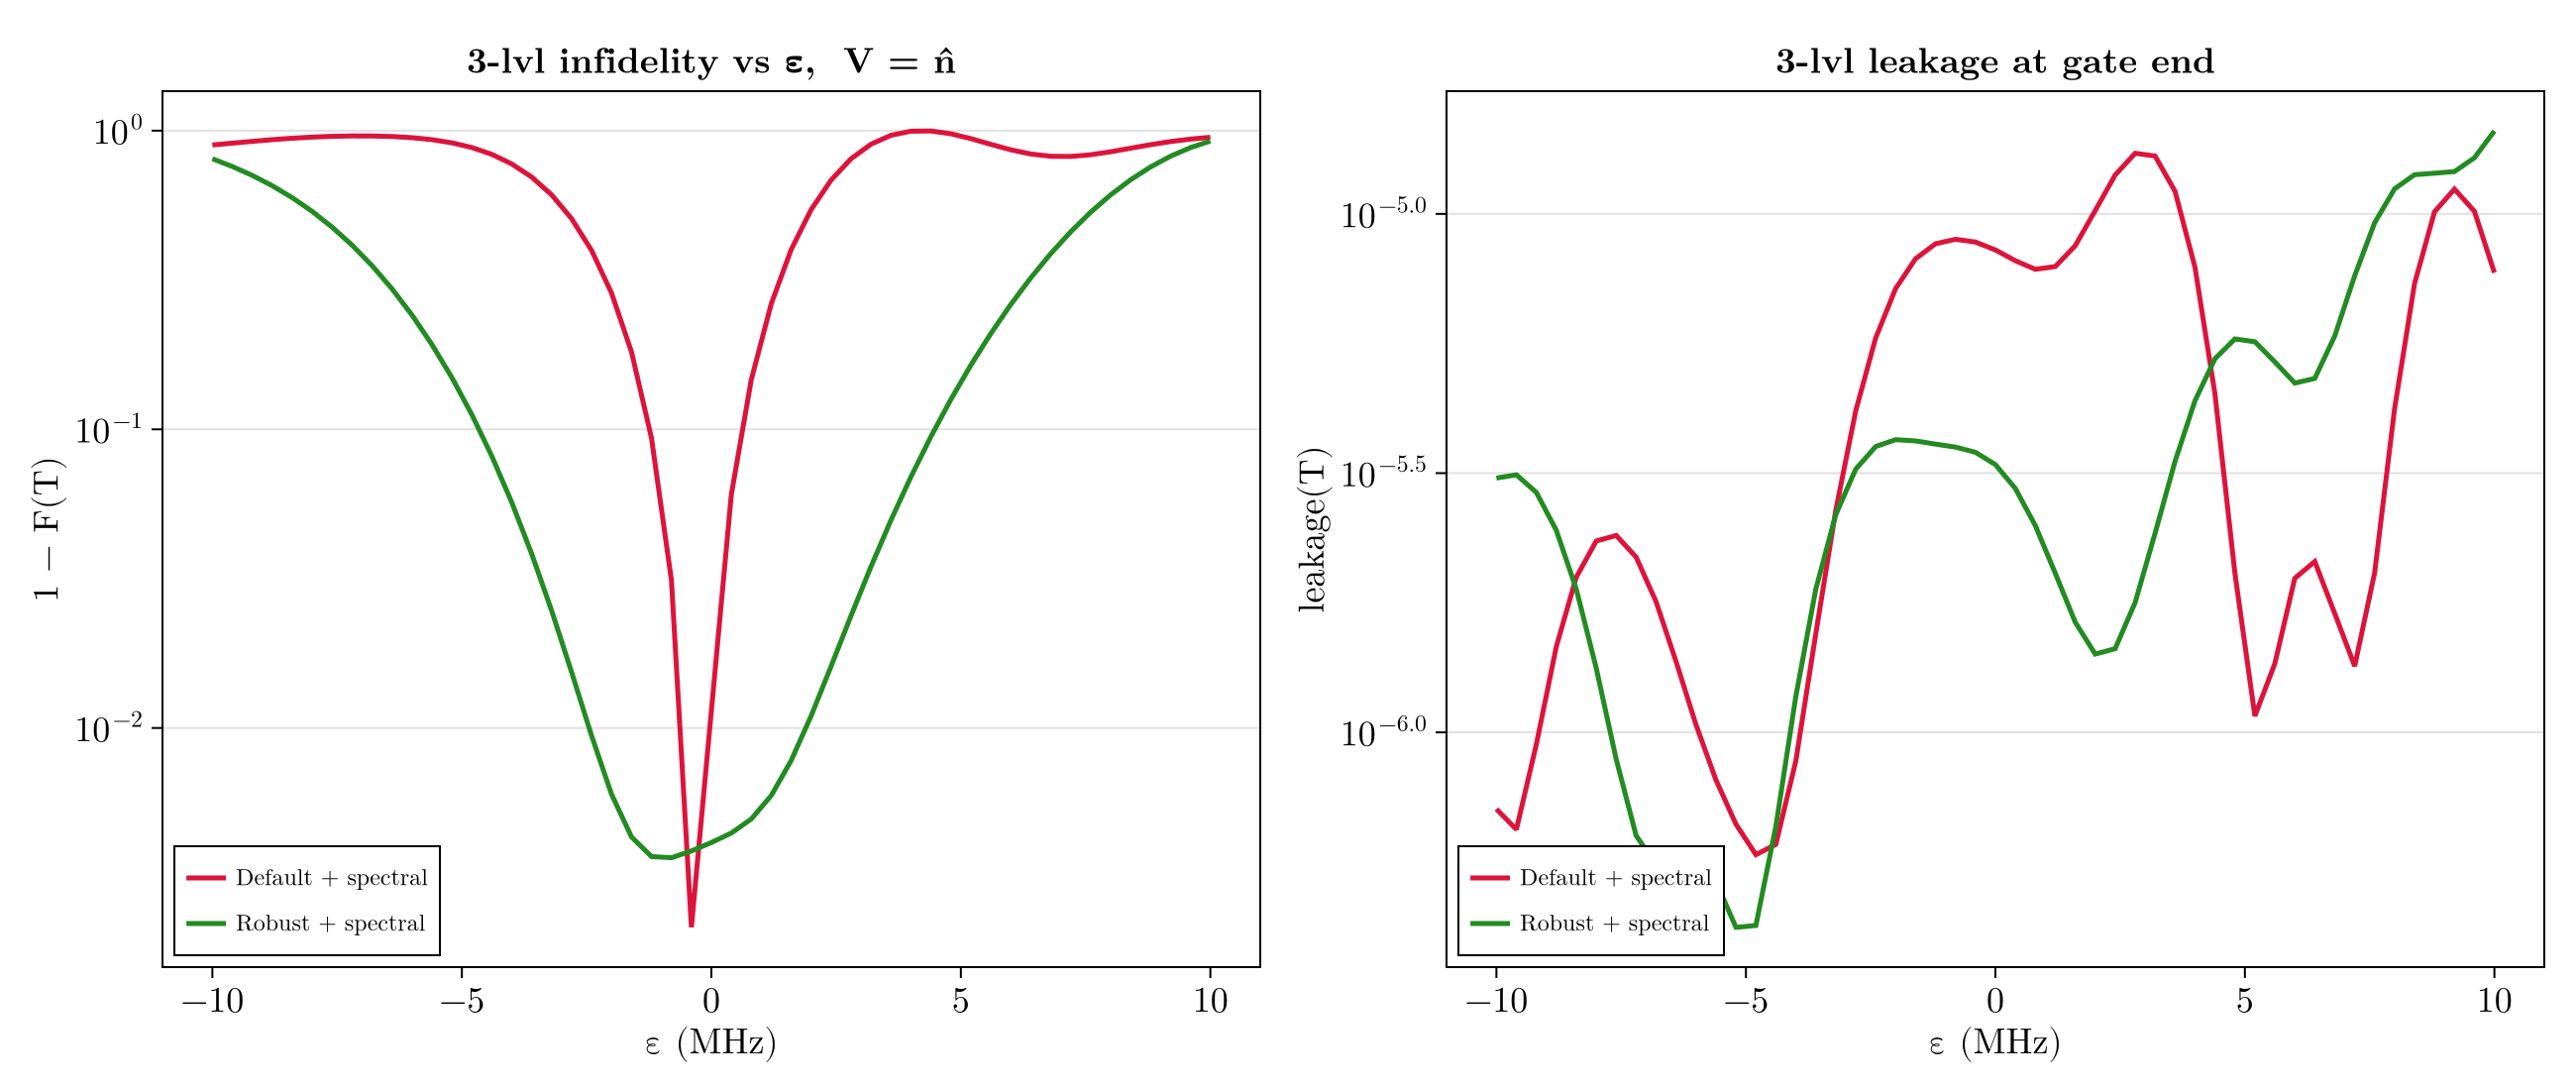

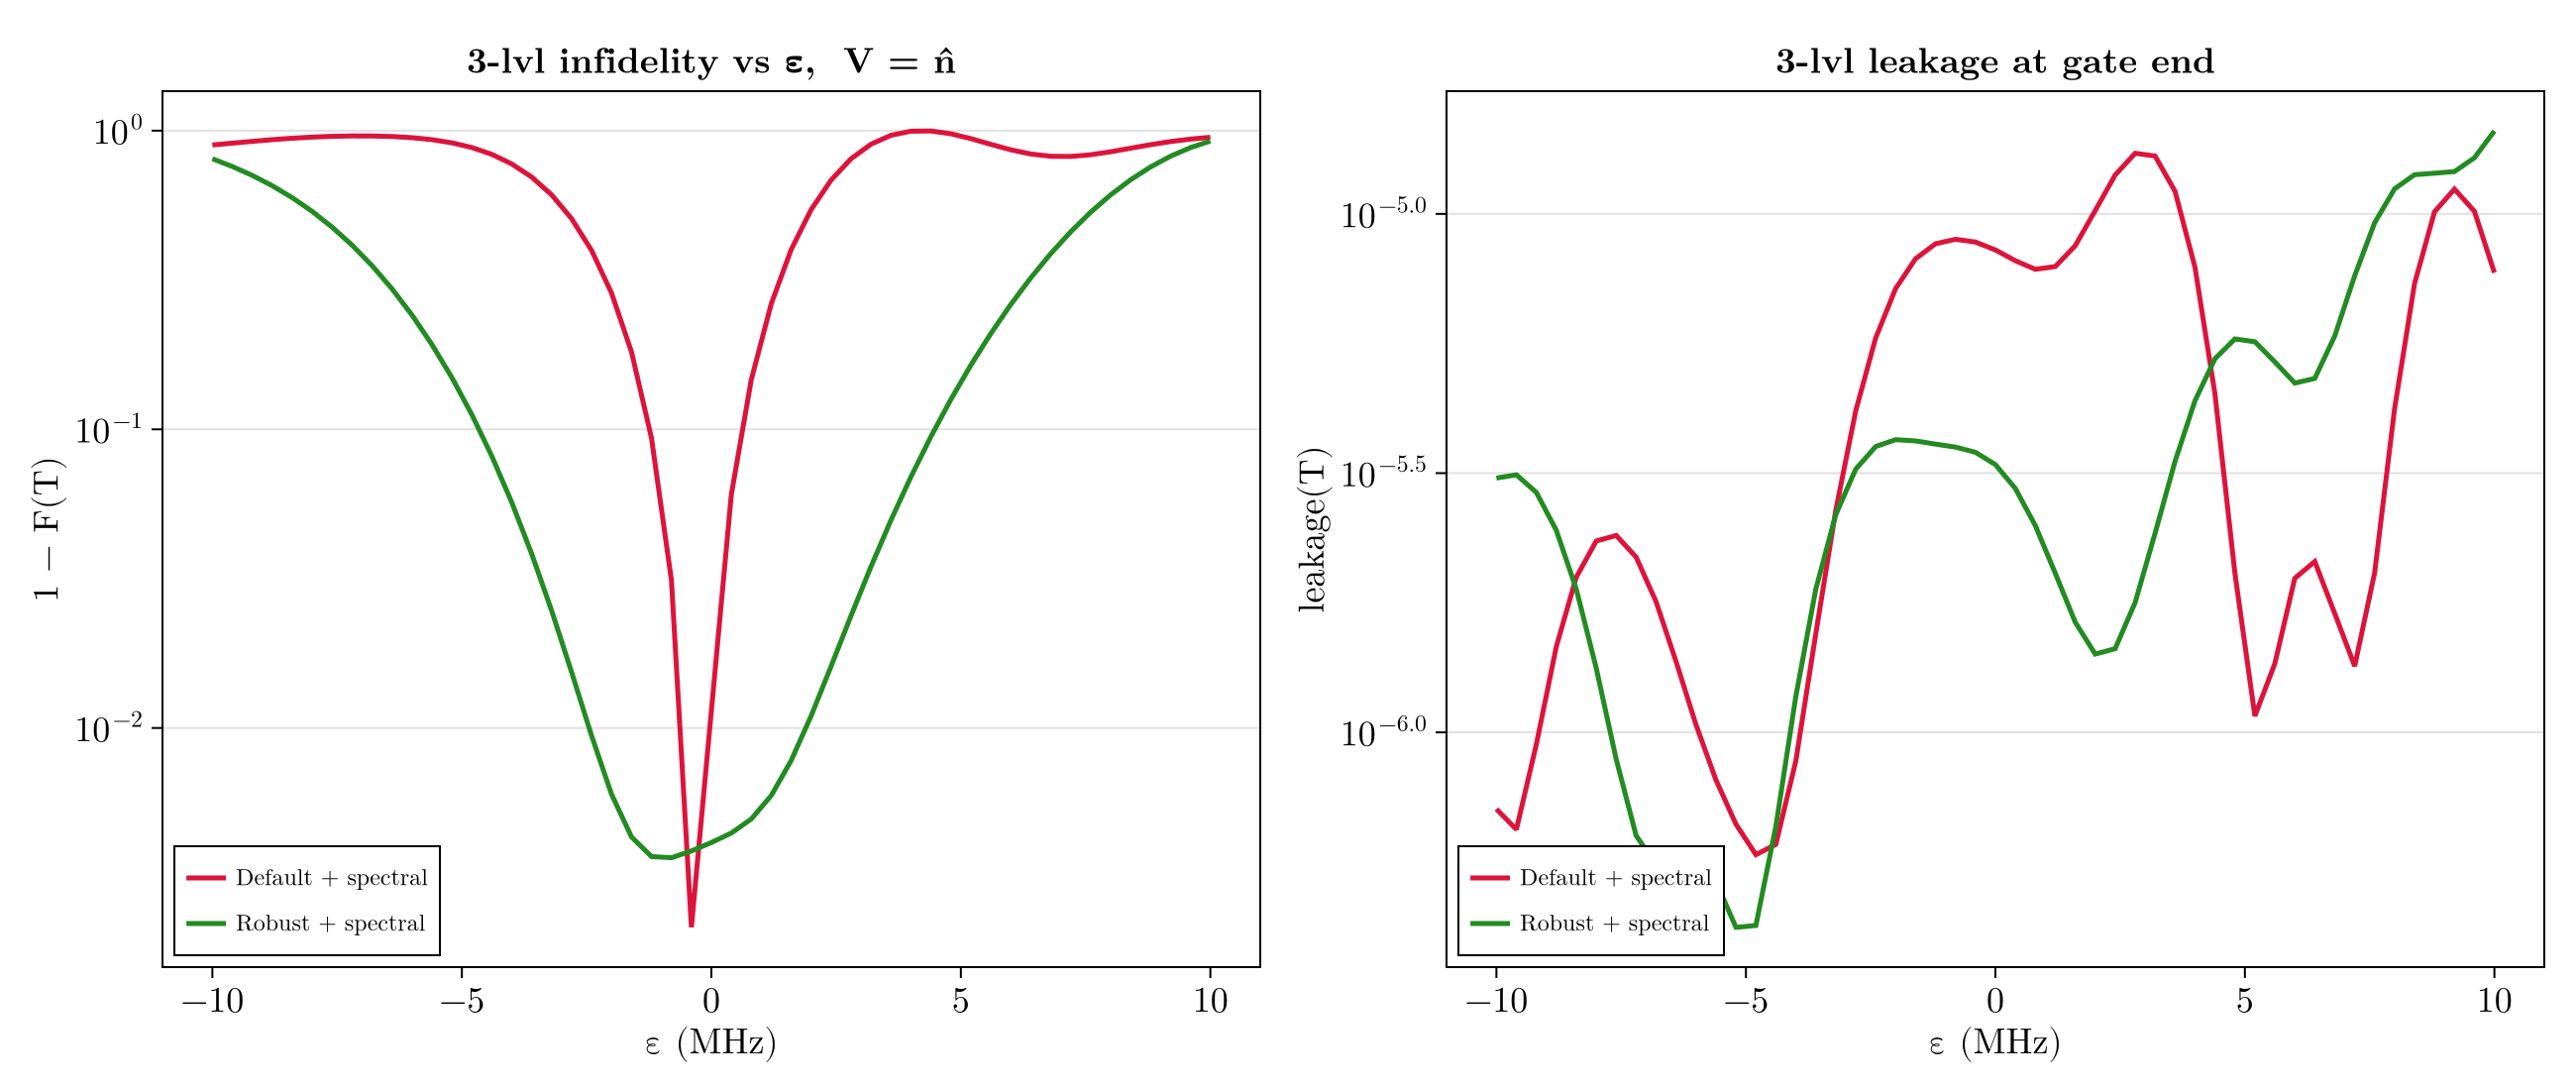

In [167]:
fig = Figure(size = (1300, 550), fontsize = 18)
ax_F = Axis(fig[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F(T)", yscale = log10, title = "3-lvl infidelity vs ε,  V = n̂")
ax_L = Axis(fig[1, 2]; xlabel = "ε (MHz)", ylabel = "leakage(T)",
    yscale = log10, title = "3-lvl leakage at gate end")

for (lbl, F, L, c) in [
        ("Default + spectral", F3_dp, L3_dp, :crimson),
        ("Robust + spectral",  F3_rp, L3_rp, :forestgreen),
    ]
    lines!(ax_F, εs_MHz, max.(1 .- F, 1e-12);
        color = c, linewidth = 2.5, label = lbl)
    lines!(ax_L, εs_MHz, max.(L, 1e-12);
        color = c, linewidth = 2.5, label = lbl)
end
axislegend(ax_F; position = :lb, labelsize = 12)
axislegend(ax_L; position = :lb, labelsize = 12)
display(fig)
save(joinpath(@__DIR__, "spectral_F_L_vs_eps_3lvl.png"), fig; px_per_unit = 4)
fig


## Summary table

In [168]:
mid = (length(εs) + 1) ÷ 2
@printf("\n%-24s | F_2lvl(0)  | F_3lvl(0)  | L_3lvl(0)  | |Ω̂(η)|\n", "pulse")
@printf("%s\n", "-"^85)
for (lbl, traj, _) in panels
    F2 = honest_F_2lvl(traj)
    F3, L3 = F_L_3lvl(traj)
    fs_MHz, mag = envelope_spectrum(traj)
    Ω_at_η = mag[argmin(abs.(fs_MHz .- abs(η_MHz)))]
    @printf("%-24s | %.6f   | %.6f   | %.3e   | %.3e\n",
        lbl, F2, F3, L3, Ω_at_η)
end


pulse                    | F_2lvl(0)  | F_3lvl(0)  | L_3lvl(0)  | |Ω̂(η)|
-------------------------------------------------------------------------------------
Default + spectral       | 0.999998   | 0.988585   | 8.520e-06   | 1.348e-04
Robust + spectral        | 0.999998   | 0.995866   | 3.284e-06   | 2.354e-04


## Spectral notch experiment

Apply a Gaussian notch `mask(f) = 1 − G(f − |η|, σ_notch)` to the optimized envelope's Fourier transform, IFFT back, and compare F + leakage of the raw vs notched pulse for both default and robust.

Tests whether enforcing a spectral hole at the leakage frequency *post-hoc* preserves F_2lvl (i.e., is the natural |Ω̂(η)| small enough that masking is free).

In [169]:
# Dense spectrum + notch + dense-grid propagators
function envelope_spectrum_dense(traj; N_dense = 16384)
    sp_X, sp_Y = spline_uXuY(traj)
    ts_d = collect(range(0.0, T_NS, length = N_dense))
    dt_d = ts_d[2] - ts_d[1]
    Ω = [sp_X(t) + im * sp_Y(t) for t in ts_d]
    Ω̂ = fftshift(fft(Ω)) * dt_d
    fs = fftshift(fftfreq(N_dense, 1/dt_d))
    return ts_d, dt_d, Ω, Ω̂, fs .* 1e3
end

const σ_NOTCH_MHz = 30.0                              # notch width
const f_NOTCH_MHz = abs(η_anh) / (2π) * 1e3           # +|η|/2π ≈ +170 MHz

function apply_spectral_notch(traj; N_dense = 16384, σ_notch_MHz = σ_NOTCH_MHz)
    ts_d, dt_d, Ω, Ω̂, fs_MHz = envelope_spectrum_dense(traj; N_dense = N_dense)
    mask = 1.0 .- exp.(-0.5 .* ((fs_MHz .- f_NOTCH_MHz) ./ σ_notch_MHz).^2)
    Ω̂_notched = Ω̂ .* mask
    Ω_notched = ifft(ifftshift(Ω̂_notched)) ./ dt_d
    return ts_d, real.(Ω), imag.(Ω),
           real.(Ω_notched), imag.(Ω_notched),
           fs_MHz, abs.(Ω̂), abs.(Ω̂_notched), mask
end

function propagate_2lvl_dense(uX, uY, dt, ε = 0.0)
    U = Matrix{ComplexF64}(I, 2, 2)
    for k in 1:length(uX) - 1
        uXm = 0.5 * (uX[k] + uX[k+1])
        uYm = 0.5 * (uY[k] + uY[k+1])
        H = uXm * σx + uYm * σy + ε * σz
        U = exp(-im * dt * H) * U
    end
    return U
end

function FL_3lvl_dense(uX, uY, dt, ε = 0.0)
    U = Matrix{ComplexF64}(I, 3, 3)
    for k in 1:length(uX) - 1
        uXm = 0.5 * (uX[k] + uX[k+1])
        uYm = 0.5 * (uY[k] + uY[k+1])
        H = H_anh3 + uXm * X3 + uYm * Y3 + ε * n3
        U = exp(-im * dt * H) * U
    end
    Usub = U[subspace_indices, subspace_indices]
    F = abs2(tr(U_target' * Usub)) / 4
    L = 1 - real(tr(Usub' * Usub)) / 2
    return F, L
end

F_2lvl_dense(uX, uY, dt) = abs2(tr(U_target' * propagate_2lvl_dense(uX, uY, dt))) / 4

println("Notch helpers + dense-grid propagators defined.")

Notch helpers + dense-grid propagators defined.


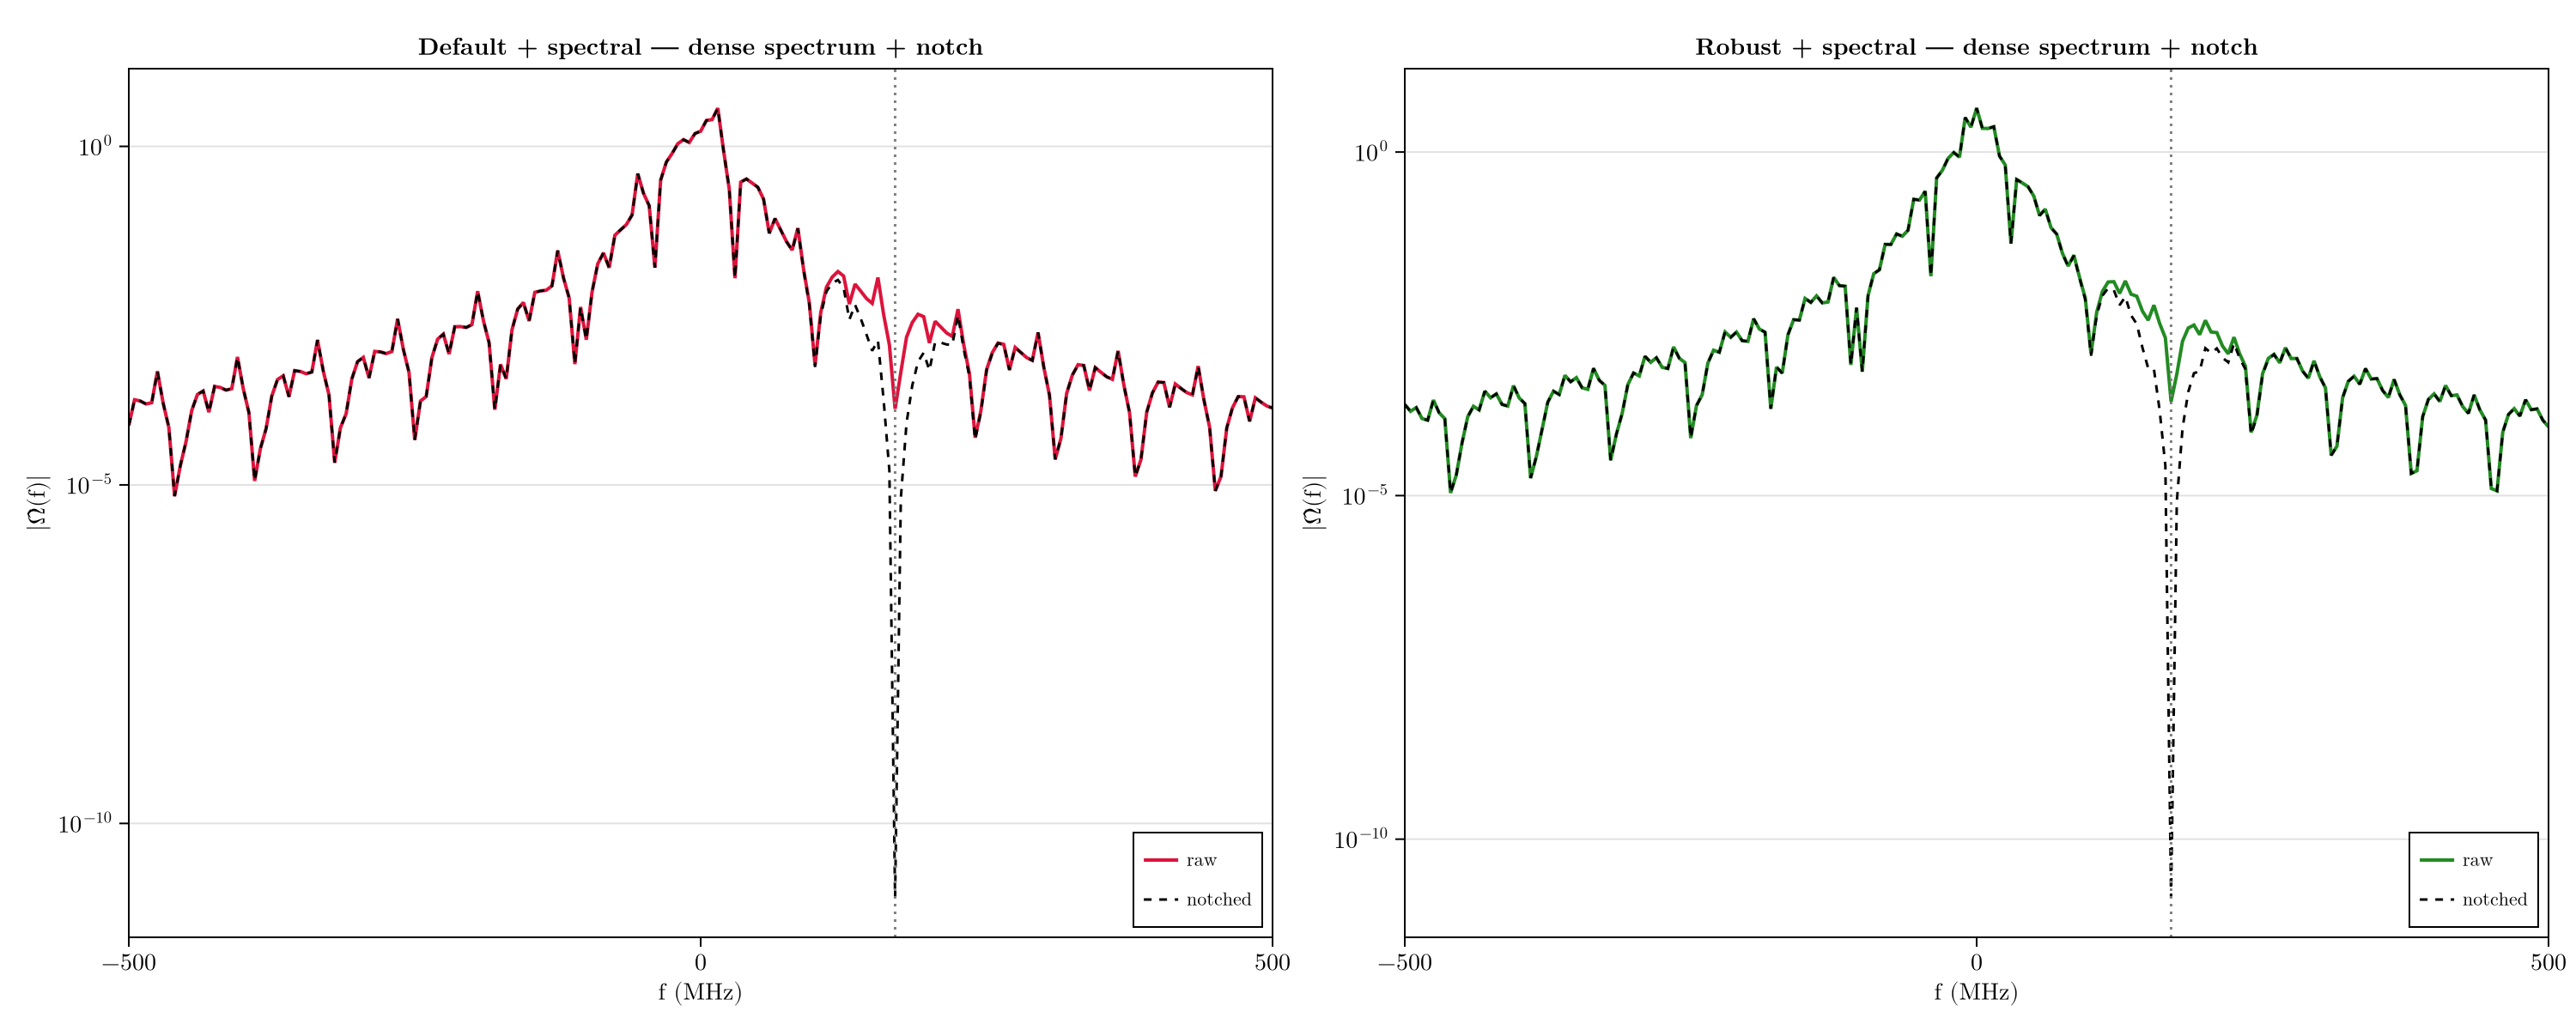

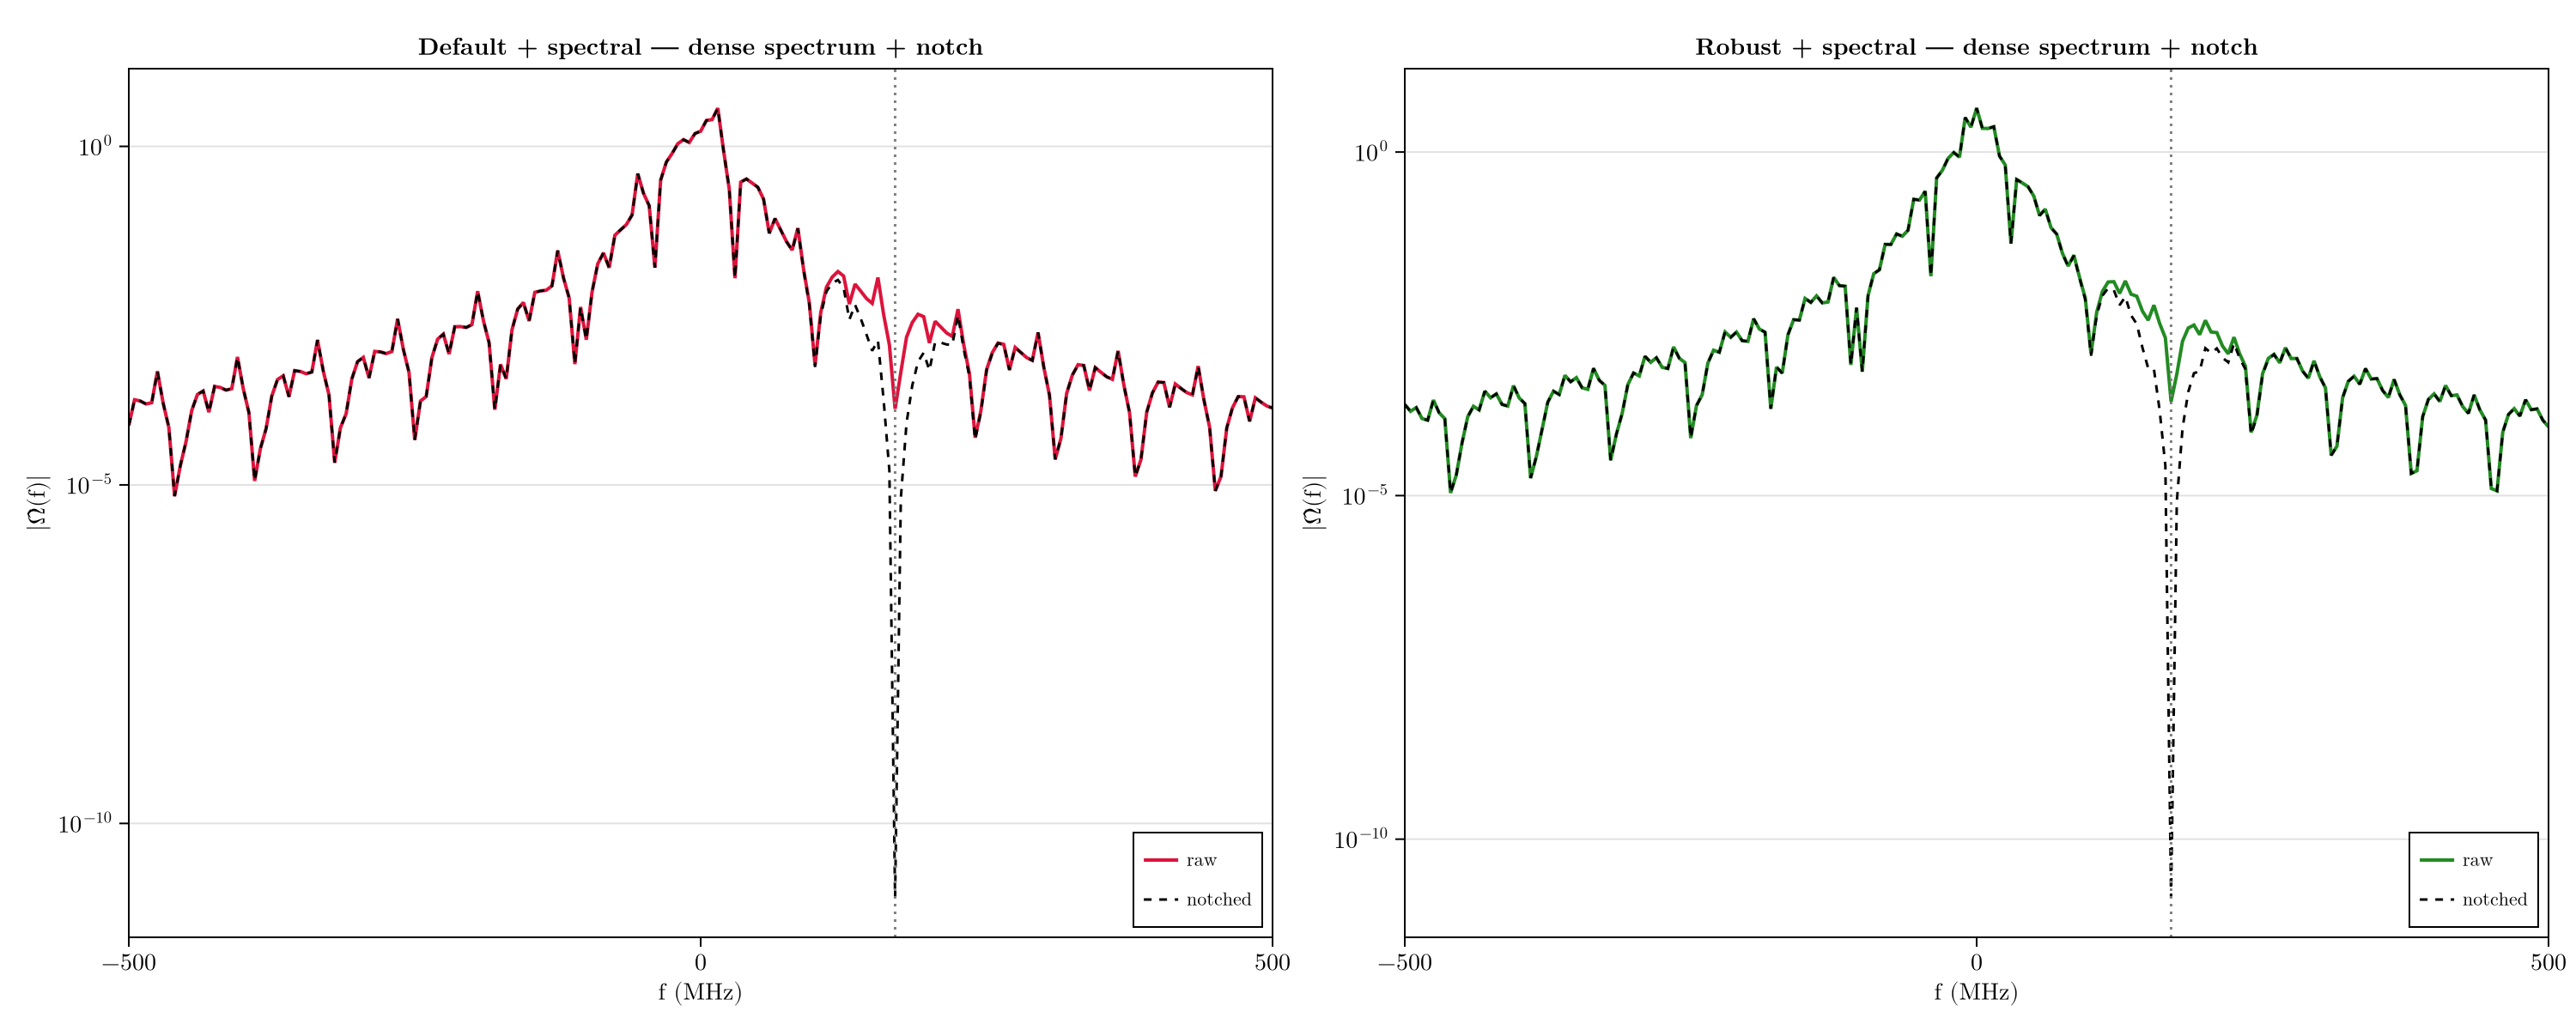

In [170]:
# Run notch + simulate; collect results
results_table = []
for (lbl, traj, c) in panels
    ts_d, uX, uY, uX_n, uY_n, fs_MHz, mag, mag_n, mask =
        apply_spectral_notch(traj; N_dense = 16384, σ_notch_MHz = σ_NOTCH_MHz)
    dt_d = ts_d[2] - ts_d[1]
    F2_raw = F_2lvl_dense(uX, uY, dt_d)
    F2_n   = F_2lvl_dense(uX_n, uY_n, dt_d)
    F3_raw, L3_raw = FL_3lvl_dense(uX, uY, dt_d)
    F3_n,   L3_n   = FL_3lvl_dense(uX_n, uY_n, dt_d)
    push!(results_table, (lbl, F2_raw, F2_n, F3_raw, F3_n, L3_raw, L3_n,
                          ts_d, uX, uY, uX_n, uY_n, fs_MHz, mag, mag_n, mask, c))
end

# Dense spectrum plot (raw vs notched)
fig_spec = Figure(size = (1500, 600), fontsize = 14)
for (i, r) in enumerate(results_table)
    lbl, _, _, _, _, _, _, _, _, _, _, _, fs_MHz, mag, mag_n, mask, c = r
    ax = Axis(fig_spec[1, i]; xlabel = "f (MHz)", ylabel = "|Ω̂(f)|",
        yscale = log10, title = "$lbl — dense spectrum + notch")
    lines!(ax, fs_MHz, max.(mag,   1e-12); color = c,      linewidth = 2.0, label = "raw")
    lines!(ax, fs_MHz, max.(mag_n, 1e-12); color = :black, linewidth = 1.5, linestyle = :dash, label = "notched")
    vlines!(ax, [f_NOTCH_MHz]; color = :gray, linestyle = :dot, linewidth = 1.5)
    xlims!(ax, -500, 500)
    axislegend(ax; position = :rb, labelsize = 11)
end
display(fig_spec)
save(joinpath(@__DIR__, "spectral_notch_freq.png"), fig_spec; px_per_unit = 4)
fig_spec

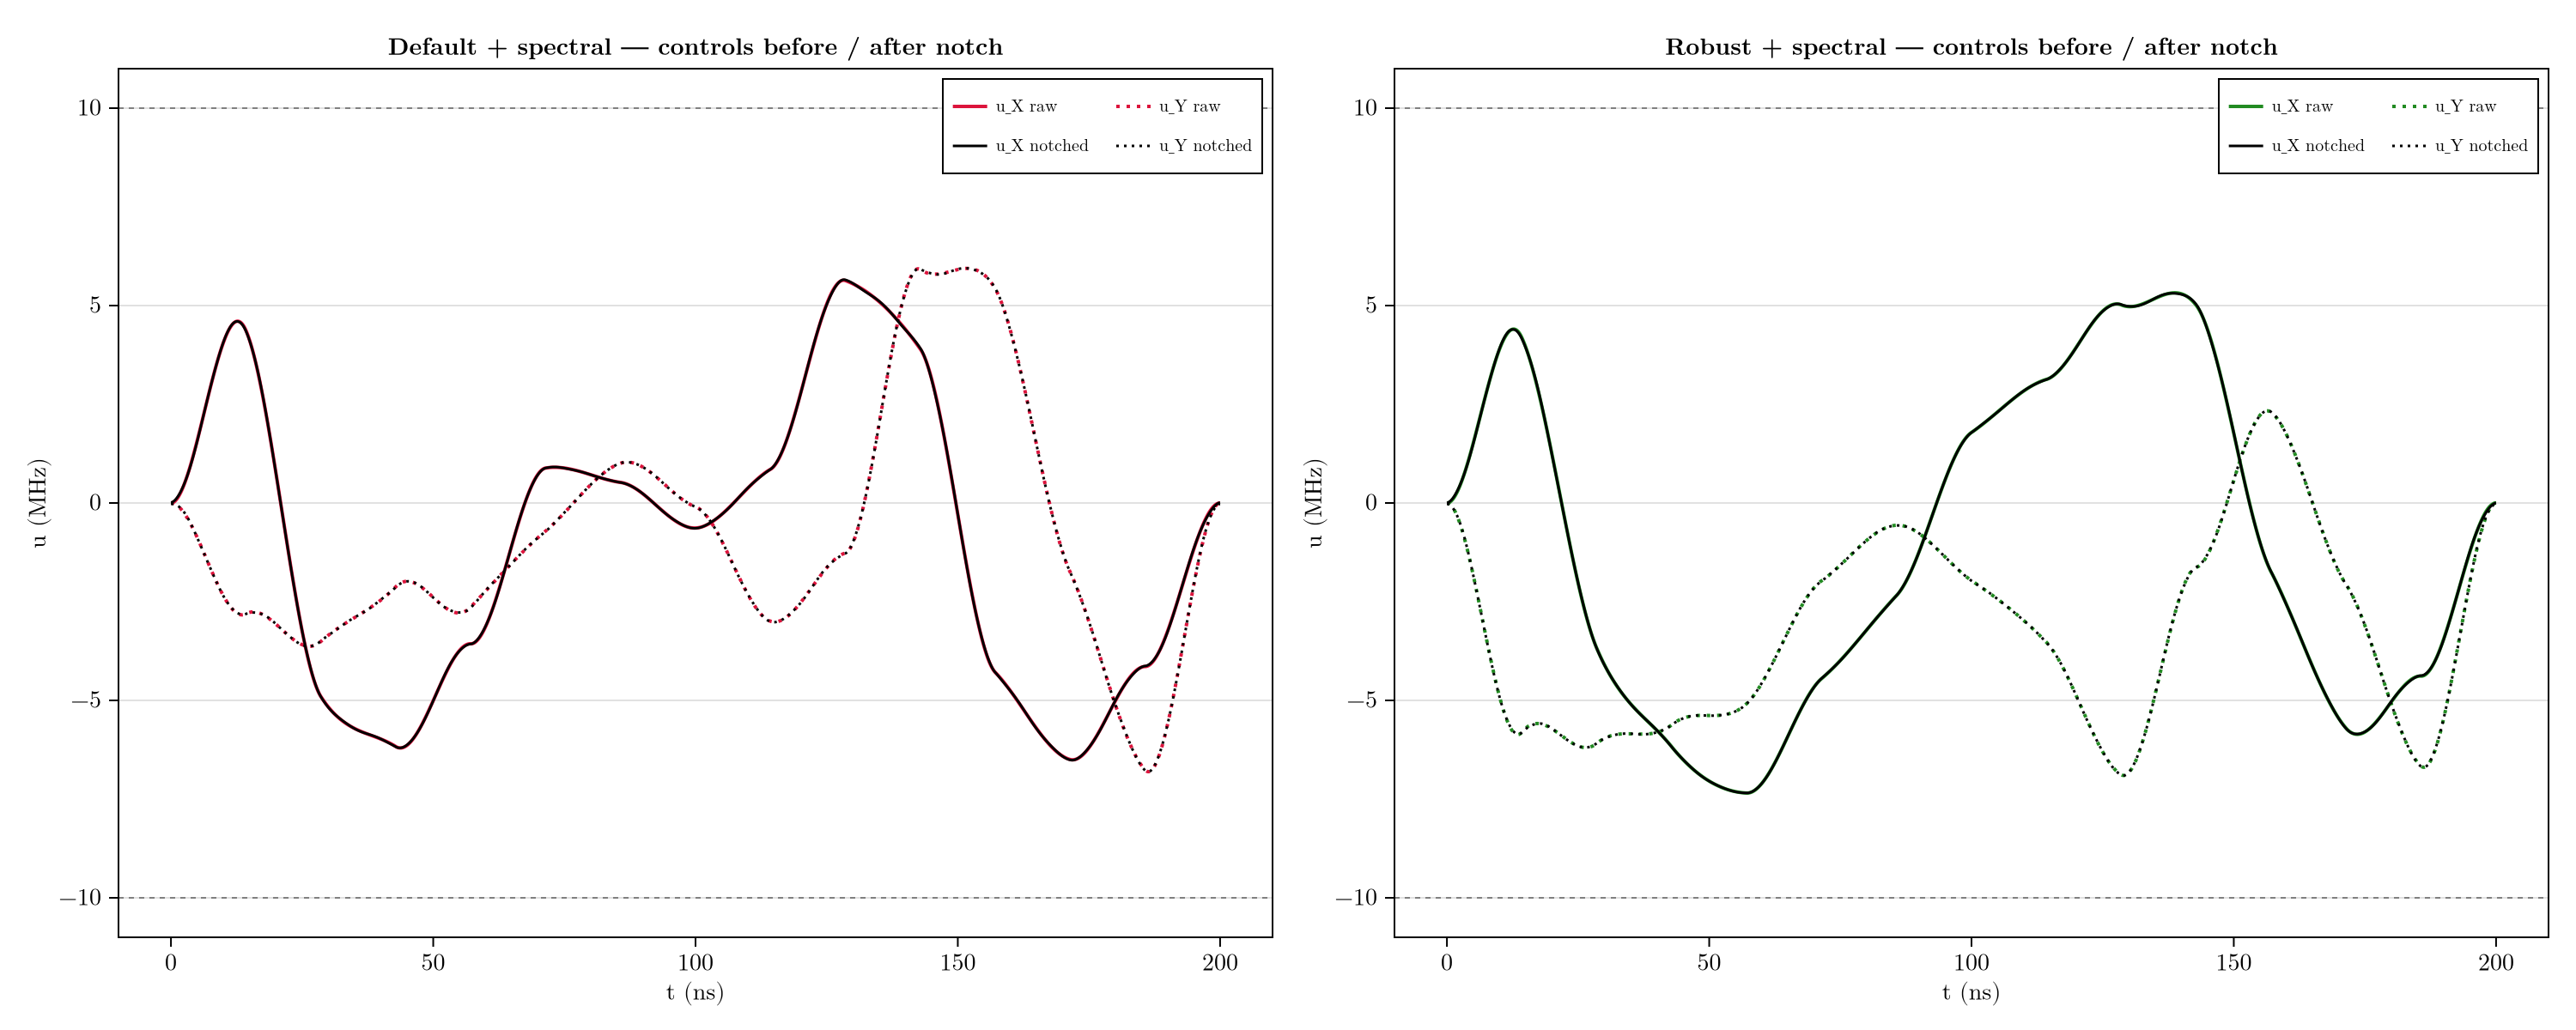

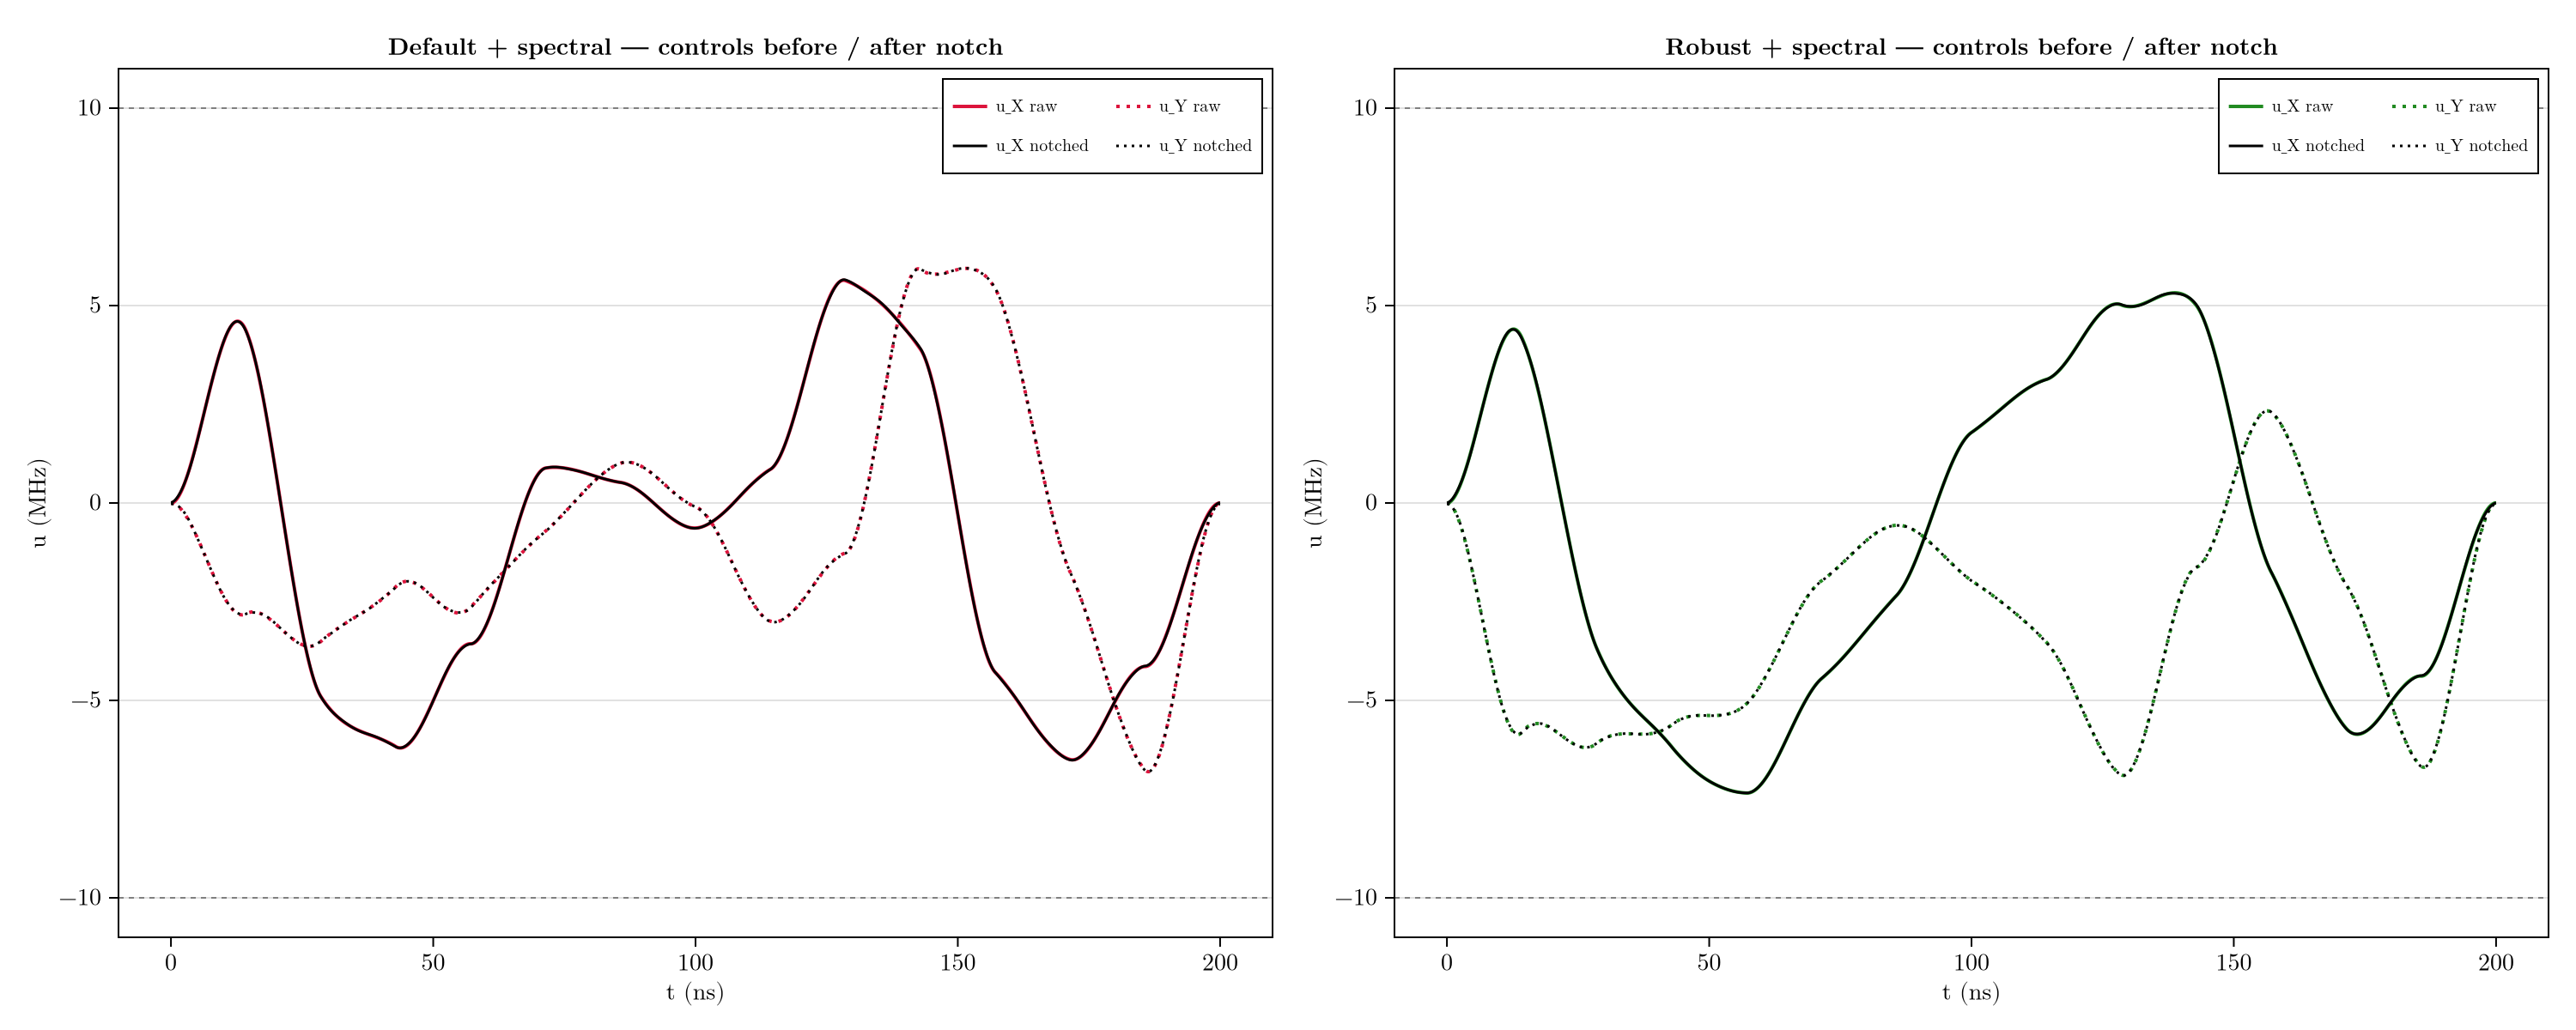

In [171]:
# Time-domain plot (controls before / after notch)
fig_time = Figure(size = (1500, 600), fontsize = 14)
for (i, r) in enumerate(results_table)
    lbl, _, _, _, _, _, _, ts_d, uX, uY, uX_n, uY_n, _, _, _, _, c = r
    ax = Axis(fig_time[1, i]; xlabel = "t (ns)", ylabel = "u (MHz)",
        title = "$lbl — controls before / after notch")
    lines!(ax, ts_d, uX   .* MHz_per_radperns; color = c,      linewidth = 2.0, label = "u_X raw")
    lines!(ax, ts_d, uY   .* MHz_per_radperns; color = c,      linewidth = 2.0, linestyle = :dot, label = "u_Y raw")
    lines!(ax, ts_d, uX_n .* MHz_per_radperns; color = :black, linewidth = 1.5, label = "u_X notched")
    lines!(ax, ts_d, uY_n .* MHz_per_radperns; color = :black, linewidth = 1.5, linestyle = :dot, label = "u_Y notched")
    hlines!(ax, [a_bound, -a_bound] .* MHz_per_radperns; color = :gray, linestyle = :dash, linewidth = 1)
    axislegend(ax; position = :rt, labelsize = 10, nbanks = 2)
end
display(fig_time)
save(joinpath(@__DIR__, "spectral_notch_time.png"), fig_time; px_per_unit = 4)
fig_time

In [172]:
# Summary table: F_2lvl, F_3lvl, L_3lvl  before vs after notch
@printf("\n%-25s | %-9s | %-9s | %-9s | %-9s | %-10s | %-10s\n",
    "pulse", "F2_raw", "F2_notch", "F3_raw", "F3_notch", "L3_raw", "L3_notch")
println("-"^115)
for r in results_table
    lbl, F2_raw, F2_n, F3_raw, F3_n, L3_raw, L3_n = r[1:7]
    @printf("%-25s | %.6f | %.6f | %.6f | %.6f | %.3e  | %.3e\n",
        lbl, F2_raw, F2_n, F3_raw, F3_n, L3_raw, L3_n)
end


pulse                     | F2_raw    | F2_notch  | F3_raw    | F3_notch  | L3_raw     | L3_notch  
-------------------------------------------------------------------------------------------------------------------
Default + spectral        | 0.999998 | 0.999997 | 0.988580 | 0.988585 | 8.546e-06  | 4.524e-07
Robust + spectral         | 0.999998 | 0.999998 | 0.995865 | 0.995876 | 3.293e-06  | 9.465e-07


In [173]:
function F3_with_virtualZ(traj, ε_MHz; N_fine = 4000)
    us = traj[:u]; dus = traj[:du]
    ts_knots = collect(range(0.0, T_NS, length = size(us, 2)))
    sp_X = CubicHermiteSpline(dus[1, :], us[1, :], ts_knots)
    sp_Y = CubicHermiteSpline(dus[2, :], us[2, :], ts_knots)
    ts_f = collect(range(0.0, T_NS, length = N_fine))
    dt_sub = ts_f[2] - ts_f[1]
    ε_rad = 2π * ε_MHz * 1e-3            # MHz -> rad/ns
    U3 = Matrix{ComplexF64}(I, 3, 3)
    for k in 1:N_fine - 1
        t_mid = 0.5 * (ts_f[k] + ts_f[k+1])
        H = H_anh3 + sp_X(t_mid) * X3 + sp_Y(t_mid) * Y3 + ε_rad * n3
        U3 = exp(-im * dt_sub * H) * U3
    end
    Usub = U3[subspace_indices, subspace_indices]
    L    = 1 - real(tr(Usub' * Usub)) / 2
    A    = U_target' * Usub
    F_vZ = (abs(A[1,1]) + abs(A[2,2]))^2 / 4
    φ_star = angle(A[1,1]) - angle(A[2,2])
    return F_vZ, L, φ_star
end

F3_with_virtualZ (generic function with 1 method)

In [178]:
F3_dp_vZ = Float64[]; φ_dp_vZ = Float64[]
F3_rp_vZ = Float64[]; φ_rp_vZ = Float64[]

for ε in εs_MHz
    Fd, _, φd = F3_with_virtualZ(traj_d_prox, ε)
    Fr, _, φr = F3_with_virtualZ(traj_r_prox, ε)
    push!(F3_dp_vZ, Fd); push!(φ_dp_vZ, φd)
    push!(F3_rp_vZ, Fr); push!(φ_rp_vZ, φr)
end

@printf("ε=0  Default : 1−F₃(raw)=%.3e  →  1−F₃(vZ)=%.3e   φ*=%.4f rad\n",
    1 - F3_dp[1], 1 - F3_dp_vZ[1], φ_dp_vZ[1])
@printf("ε=0  Robust  : 1−F₃(raw)=%.3e  →  1−F₃(vZ)=%.3e   φ*=%.4f rad\n",
    1 - F3_rp[1], 1 - F3_rp_vZ[1], φ_rp_vZ[1])

ε=0  Default : 1−F₃(raw)=8.954e-01  →  1−F₃(vZ)=7.441e-02   φ*=2.4559 rad
ε=0  Robust  : 1−F₃(raw)=8.048e-01  →  1−F₃(vZ)=5.333e-01   φ*=-1.7351 rad


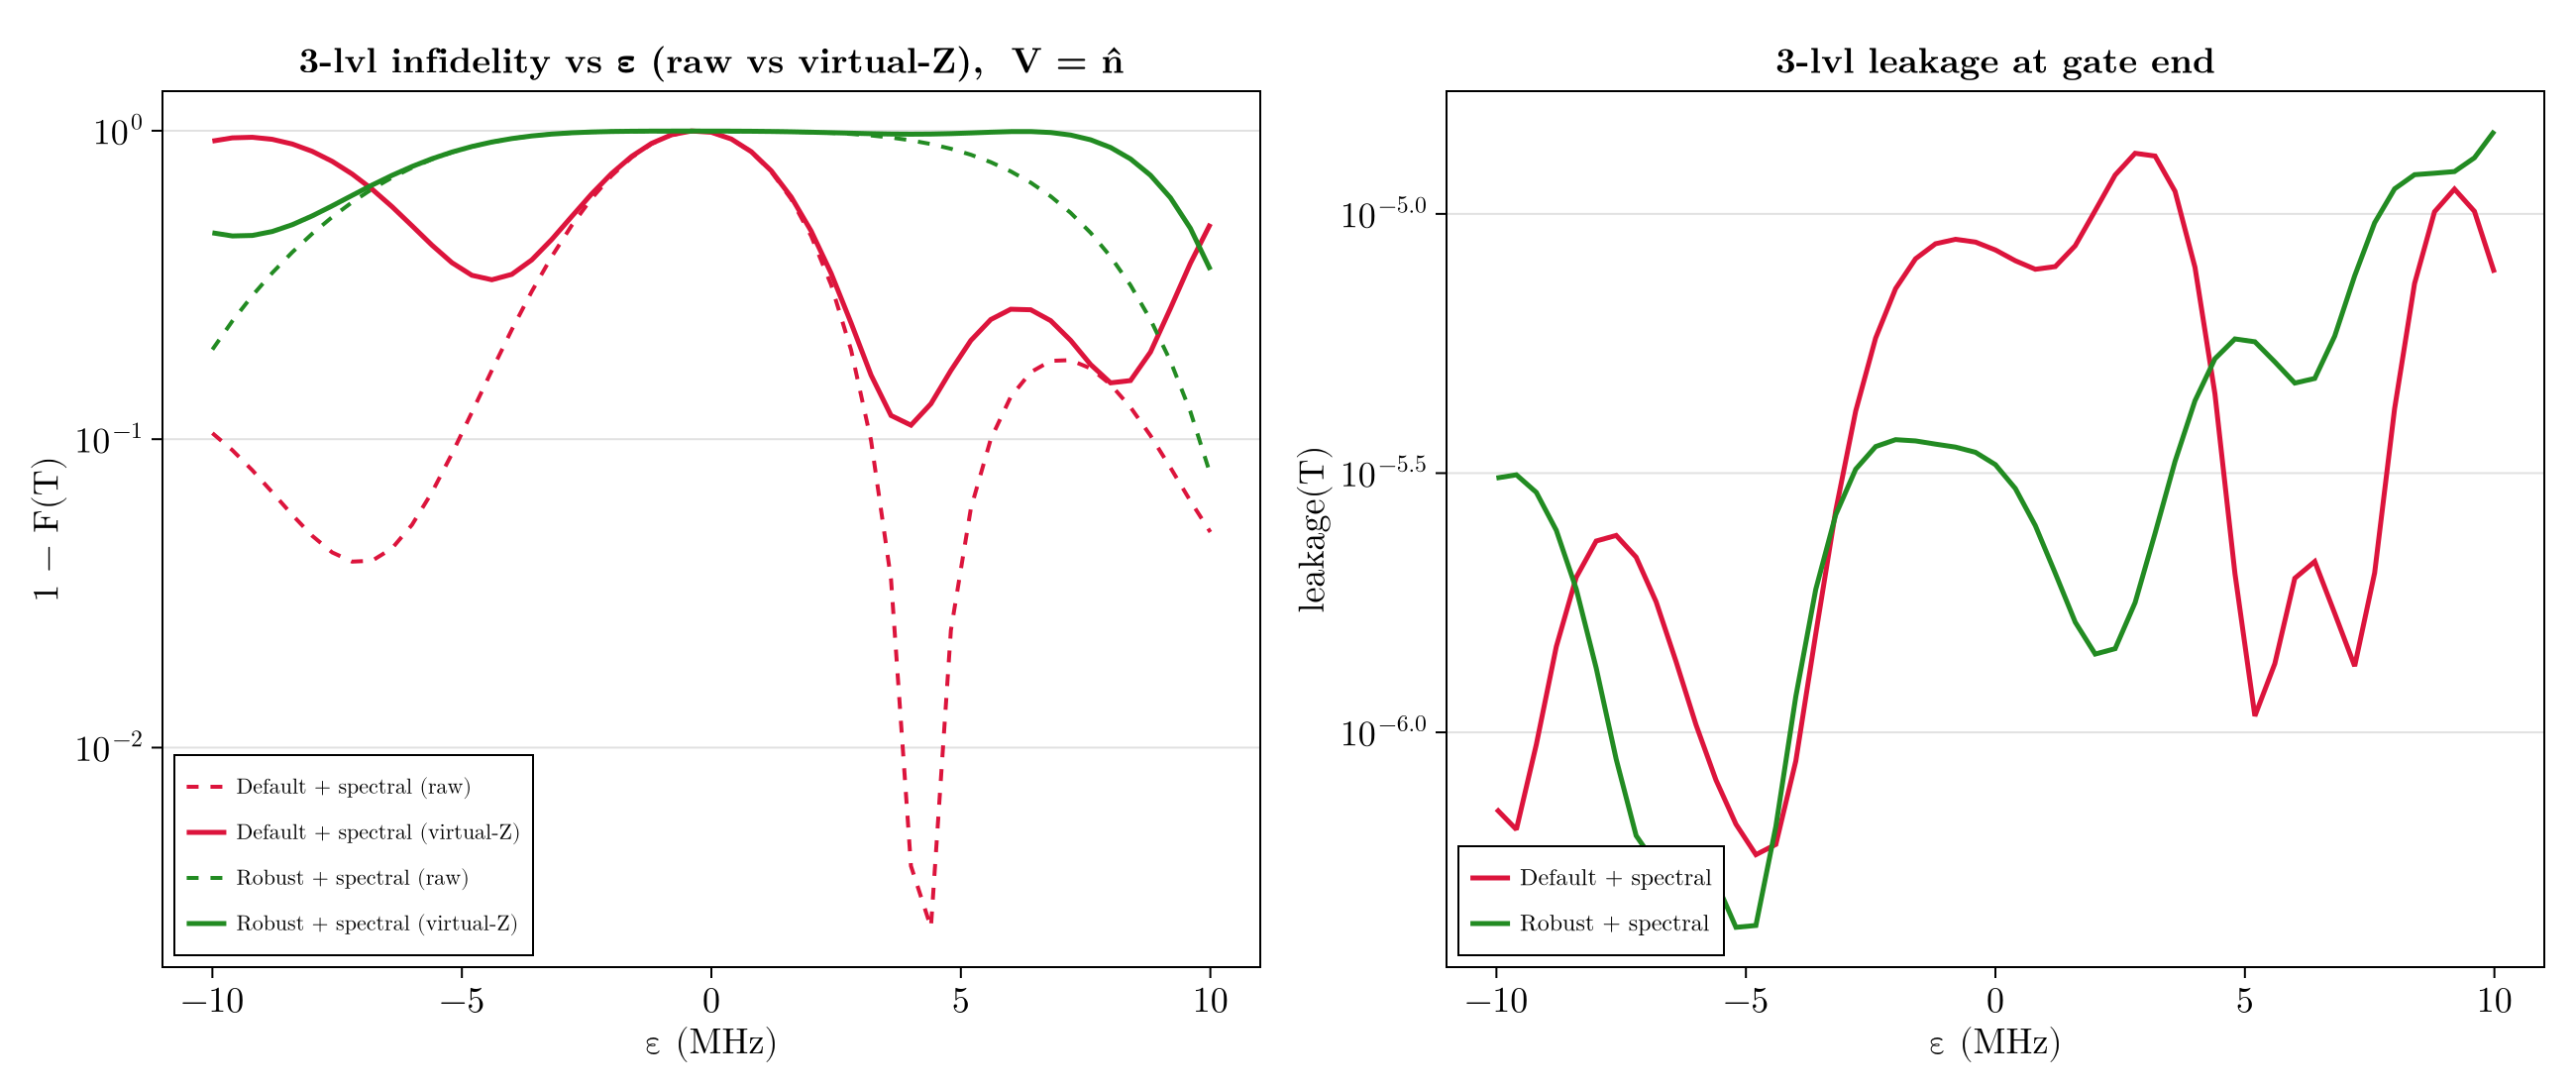

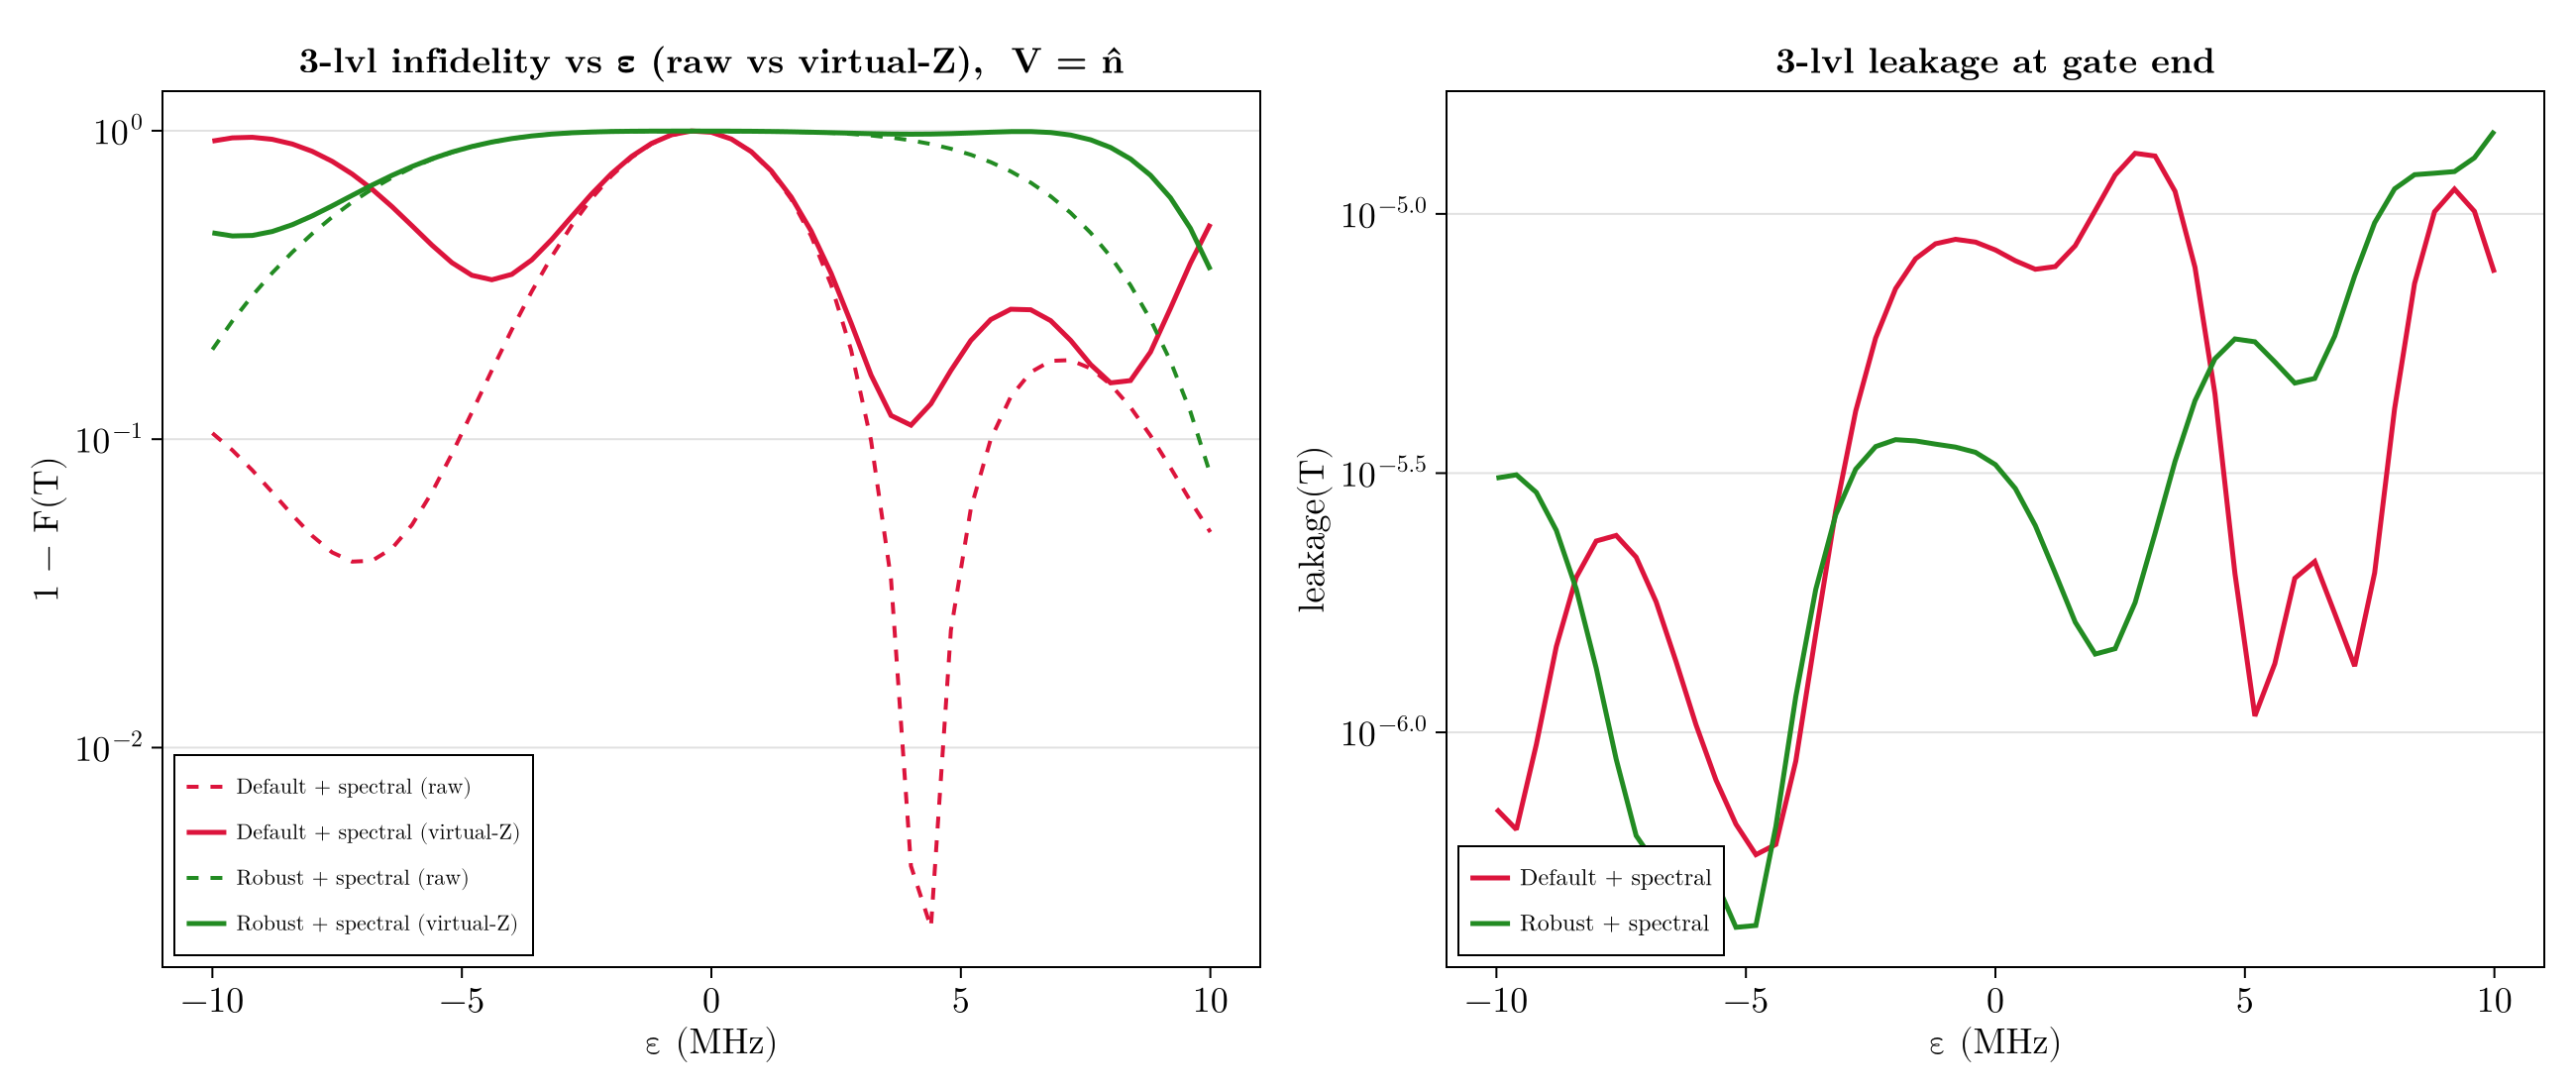

In [187]:
fig = Figure(size = (1300, 550), fontsize = 18)
ax_F = Axis(fig[1, 1]; xlabel = "ε (MHz)", ylabel = "1 − F(T)", yscale = log10,
    title = "3-lvl infidelity vs ε (raw vs virtual-Z),  V = n̂")
ax_L = Axis(fig[1, 2]; xlabel = "ε (MHz)", ylabel = "leakage(T)",
    yscale = log10, title = "3-lvl leakage at gate end")

for (lbl, F_raw, F_vZ, L, c) in [
        ("Default + spectral", F3_dp, F3_dp_vZ, L3_dp, :crimson),
        ("Robust + spectral",  F3_rp, F3_rp_vZ, L3_rp, :forestgreen),
    ]
    lines!(ax_F, εs_MHz, max.(F_raw, 1e-12);
        color = c, linewidth = 2.0, linestyle = :dash, label = lbl * " (raw)")
    lines!(ax_F, εs_MHz, max.(F_vZ,  1e-12);
        color = c, linewidth = 2.5, label = lbl * " (virtual-Z)")
    lines!(ax_L, εs_MHz, max.(L, 1e-12);
        color = c, linewidth = 2.5, label = lbl)
end
axislegend(ax_F; position = :lb, labelsize = 11)
axislegend(ax_L; position = :lb, labelsize = 12)
display(fig)
save(joinpath(@__DIR__, "spectral_F_L_vs_eps_3lvl_virtualZ.png"), fig; px_per_unit = 4)
fig

In [185]:
i0 = argmin(abs.(εs_MHz))
@printf("ε used for table: εs_MHz[%d] = %.4f MHz\n\n", i0, εs_MHz[i0])

@printf("%-22s | %-9s | %-9s | %-9s | %-9s | %-9s | %-9s\n",
    "pulse", "F₂", "F₃ raw", "F₃ vZ", "1−F₃ raw", "1−F₃ vZ", "L₃")
@printf("%s\n", repeat("-", 95))
@printf("%-22s | %.6f | %.6f | %.6f | %.3e | %.3e | %.3e | φ*=%+.4f rad\n",
    "Default + spectral", F2_dp[i0], F3_dp[i0], F3_dp_vZ[i0],
    1 - F3_dp[i0], 1 - F3_dp_vZ[i0], L3_dp[i0], φ_dp_vZ[i0])
@printf("%-22s | %.6f | %.6f | %.6f | %.3e | %.3e | %.3e | φ*=%+.4f rad\n",
    "Robust + spectral",  F2_rp[i0], F3_rp[i0], F3_rp_vZ[i0],
    1 - F3_rp[i0], 1 - F3_rp_vZ[i0], L3_rp[i0], φ_rp_vZ[i0])

ε used for table: εs_MHz[26] = 0.0000 MHz

pulse                  | F₂        | F₃ raw    | F₃ vZ     | 1−F₃ raw  | 1−F₃ vZ   | L₃       
-----------------------------------------------------------------------------------------------
Default + spectral     | 0.999998 | 0.988585 | 0.988583 | 1.142e-02 | 1.142e-02 | 8.520e-06 | φ*=-0.0031 rad
Robust + spectral      | 0.999998 | 0.995866 | 0.997437 | 4.134e-03 | 2.563e-03 | 3.284e-06 | φ*=-0.0794 rad
